# Hallucination Detection on DefAn via Semantic Entropy & Embedding Geometry

This notebook implements the full Stage 3-4 pipeline on the DefAn dataset.
Stages 1 and 2 are already done: Llama-3B generated 20 responses per prompt at temperature 1.0,
and GPT-4-mini judged each response into one of four categories:

- **correct** -- response matches the reference answer
- **hallucination** -- response states a wrong fact confidently
- **refused** -- model declines to answer or says it doesn't know
- **illogical** -- response is incoherent, garbled, or off-topic

The distinction matters. A refusal is not a hallucination -- the model is acknowledging
uncertainty rather than fabricating. Illogical outputs are a different failure mode from
confident fabrication. Treating all non-correct responses as hallucinations would inflate
the hallucination rate and muddy the analysis.

How we handle this:

- All 20 response embeddings are used for feature extraction (the full geometric picture)
- Response-level EDA shows all four categories, broken down by domain and answer type
- Per-question profiles track the fraction of each label type
- The binary classification target uses only the correct-vs-hallucination ratio (refused and illogical are excluded from the vote). Questions where all 20 responses are refused/illogical are dropped.
- Refusal rate and illogical rate are computed per question and explored as potential additional features

References: Farquhar et al. (2024), Ricco et al. (2025), Lee et al. (2018), Rahman et al. (2025)

## Setup

In [38]:
# Uncomment if needed:
# !pip install -q sentence-transformers scikit-learn xgboost scipy shap matplotlib seaborn umap-learn

In [39]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

from sentence_transformers import SentenceTransformer
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.covariance import LedoitWolf
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, roc_curve
from scipy.stats import ks_2samp
from matplotlib.lines import Line2D
import xgboost as xgb
import shap

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')

try:
    import umap
    HAS_UMAP = True
except ImportError:
    HAS_UMAP = False
    print('umap-learn not installed, UMAP plots will be skipped.')

print('Imports loaded.')

Imports loaded.


In [40]:
DATA_PATH = '/Users/debanjansarkar/Desktop/Boot_Camps/spring-2026-LLM-hallucinations/data/defan_t1.0_n20.jsonl'
EMBED_CACHE = 'defan_embeddings.npy'
OUTPUT_DIR = 'defan_output'

SIM_THRESHOLD = 0.85
N_PERMUTATIONS = 10000
N_BOOTSTRAP = 2000
RANDOM_SEED = 42

# minimum questions per domain for per-domain ML analyses
# (classification, SHAP, bootstrap, XGBoost importance).
# domains below this threshold are shown in EDA but excluded from ML.
MIN_QUESTIONS_FOR_ANALYSIS = 10

# the 5 embedding-geometry features
GEO_FEATURES = ['H_sem', 'D_cos', 'M_bar', 'K', 'sig2_S']

# the 4 correctness labels from GPT-4-mini judge
LABEL_ORDER = ['correct', 'hallucination', 'refused', 'illogical']
LABEL_COLORS = {
    'correct': '#2196F3',
    'hallucination': '#E53935',
    'refused': '#FFA726',
    'illogical': '#78909C',
}

os.makedirs(OUTPUT_DIR, exist_ok=True)
np.random.seed(RANDOM_SEED)

## Load Data

In [41]:
df = pd.read_json(DATA_PATH, lines=True)
print(f'Total rows: {len(df)}')
print(f'Unique questions: {df["prompt_id"].nunique()}')
print(f'Domains: {sorted(df["domain"].unique())}')
print(f'Answer types: {sorted(df["type"].unique())}')
print()
print('Correctness distribution (response-level):')
print(df['correctness'].value_counts())
print()
spq = df.groupby('prompt_id').size()
print(f'Samples per question -- min: {spq.min()}, max: {spq.max()}, median: {spq.median()}')
print()

# questions per domain in the raw data
raw_domain_counts = df.groupby('domain')['prompt_id'].nunique().sort_values(ascending=False)
print('Questions per domain (raw):')
for dom, n in raw_domain_counts.items():
    print(f'  {dom:35s}: {n}')

Total rows: 10000
Unique questions: 500
Domains: ['Arts & Literature', 'Computer Science & Engineering', 'Economics & Business', 'General Knowledge', 'History & Geography', 'Life Sciences', 'Mathematics & Logic', 'Physical Sciences', 'Politics & Law']
Answer types: ['city', 'date', 'name', 'numeric', 'rank']

Correctness distribution (response-level):
correctness
hallucination    5040
refused          2022
correct          1907
illogical        1031
Name: count, dtype: int64

Samples per question -- min: 20, max: 20, median: 20.0

Questions per domain (raw):
  General Knowledge                  : 249
  History & Geography                : 214
  Mathematics & Logic                : 59
  Arts & Literature                  : 54
  Economics & Business               : 20
  Physical Sciences                  : 15
  Politics & Law                     : 12
  Life Sciences                      : 8
  Computer Science & Engineering     : 3


## Response-Level EDA: All Four Labels

Before aggregating to question-level, we need to understand the raw distribution of
all four correctness labels. This is the unfiltered view: every response counts equally.

In [42]:
# overall response-level breakdown
resp_counts = df['correctness'].value_counts()
resp_pcts = (resp_counts / len(df) * 100).round(1)
print('Response-level label distribution:')
for lab in LABEL_ORDER:
    if lab in resp_counts.index:
        print(f'  {lab:15s}: {resp_counts[lab]:6d}  ({resp_pcts[lab]:.1f}%)')

Response-level label distribution:
  correct        :   1907  (19.1%)
  hallucination  :   5040  (50.4%)
  refused        :   2022  (20.2%)
  illogical      :   1031  (10.3%)


In [43]:
# cross-tab: domain x correctness
ct_domain = pd.crosstab(df['domain'], df['correctness'])
# reorder columns to match LABEL_ORDER
ct_domain = ct_domain.reindex(columns=[c for c in LABEL_ORDER if c in ct_domain.columns])
print('Response counts by domain x correctness:')
display(ct_domain)
print()

ct_domain_pct = ct_domain.div(ct_domain.sum(axis=1), axis=0)
print('Proportions:')
display(ct_domain_pct.round(3))

Response counts by domain x correctness:


correctness,correct,hallucination,refused,illogical
domain,,,,
Arts & Literature,383,447,0,0
Computer Science & Engineering,0,3,0,0
Economics & Business,51,176,0,78
General Knowledge,322,1571,1836,4
History & Geography,948,2532,130,0
Life Sciences,15,95,1,19
Mathematics & Logic,131,28,48,906
Physical Sciences,51,127,2,6
Politics & Law,6,61,5,18



Proportions:


correctness,correct,hallucination,refused,illogical
domain,,,,
Arts & Literature,0.461,0.539,0.000,0.000
Computer Science & Engineering,0.000,1.000,0.000,0.000
Economics & Business,0.167,0.577,0.000,0.256
General Knowledge,0.086,0.421,0.492,0.001
History & Geography,0.263,0.701,0.036,0.000
Life Sciences,0.115,0.731,0.008,0.146
Mathematics & Logic,0.118,0.025,0.043,0.814
Physical Sciences,0.274,0.683,0.011,0.032
Politics & Law,0.067,0.678,0.056,0.200


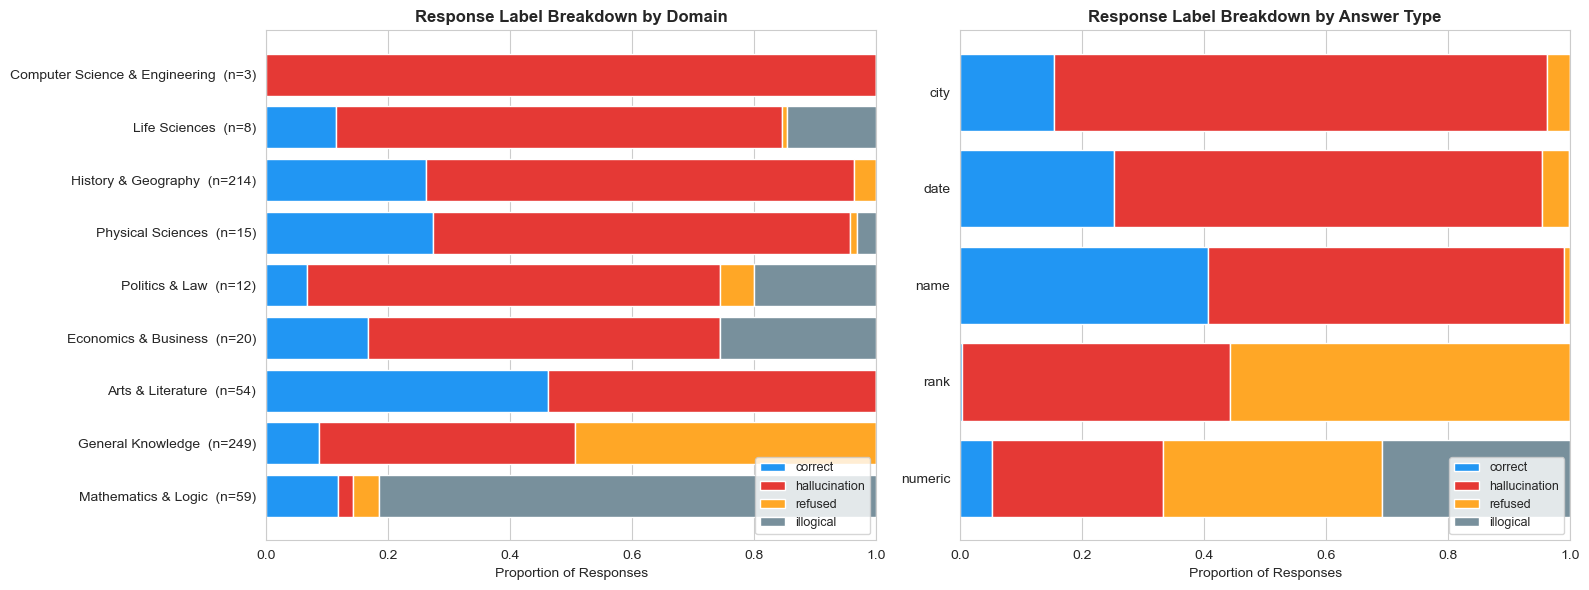

In [44]:
# stacked bar chart: domain x label proportions

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# left: stacked proportions by domain
ct_plot = ct_domain_pct.sort_values('hallucination', ascending=True)
# annotate with question count
dom_labels_left = [f'{dom}  (n={raw_domain_counts[dom]})' for dom in ct_plot.index]
bottom = np.zeros(len(ct_plot))
for lab in LABEL_ORDER:
    if lab not in ct_plot.columns:
        continue
    vals = ct_plot[lab].values
    axes[0].barh(dom_labels_left, vals, left=bottom,
                 color=LABEL_COLORS[lab], label=lab)
    bottom += vals
axes[0].set_xlabel('Proportion of Responses')
axes[0].set_title('Response Label Breakdown by Domain', fontweight='bold')
axes[0].legend(loc='lower right', fontsize=9)
axes[0].set_xlim(0, 1)

# right: same by answer type
ct_type = pd.crosstab(df['type'], df['correctness'])
ct_type = ct_type.reindex(columns=[c for c in LABEL_ORDER if c in ct_type.columns])
ct_type_pct = ct_type.div(ct_type.sum(axis=1), axis=0)
ct_type_pct = ct_type_pct.sort_values('hallucination', ascending=True)

bottom = np.zeros(len(ct_type_pct))
for lab in LABEL_ORDER:
    if lab not in ct_type_pct.columns:
        continue
    vals = ct_type_pct[lab].values
    axes[1].barh(ct_type_pct.index, vals, left=bottom,
                 color=LABEL_COLORS[lab], label=lab)
    bottom += vals
axes[1].set_xlabel('Proportion of Responses')
axes[1].set_title('Response Label Breakdown by Answer Type', fontweight='bold')
axes[1].legend(loc='lower right', fontsize=9)
axes[1].set_xlim(0, 1)

plt.tight_layout()
# plt.savefig(os.path.join(OUTPUT_DIR, 'fig01_response_label_breakdown.png'), dpi=150, bbox_inches='tight')
plt.show()

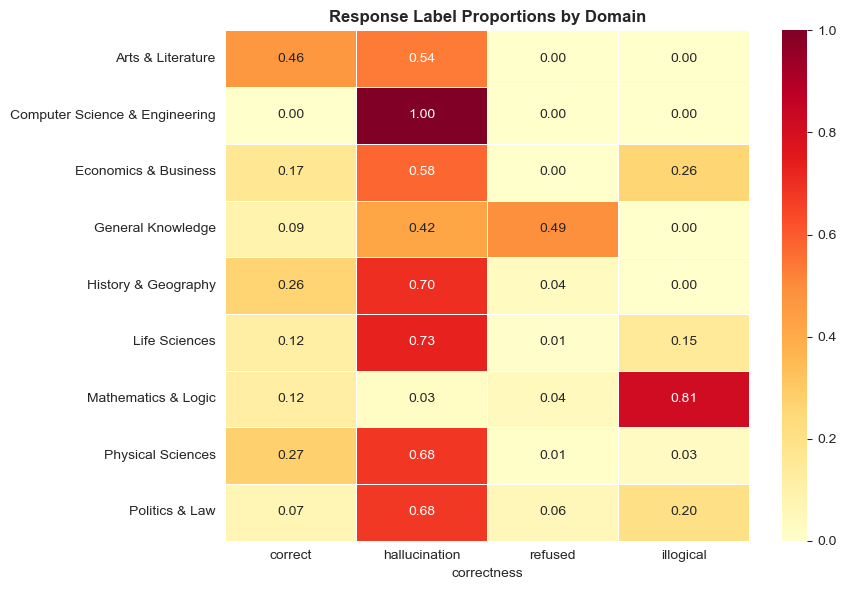

In [45]:
# heatmap of response proportions: domain x label

fig, ax = plt.subplots(figsize=(9, 6))
sns.heatmap(ct_domain_pct, annot=True, fmt='.2f', cmap='YlOrRd',
            ax=ax, linewidths=0.5, linecolor='white')
ax.set_title('Response Label Proportions by Domain', fontweight='bold')
ax.set_ylabel('')
plt.tight_layout()
# plt.savefig(os.path.join(OUTPUT_DIR, 'fig02_response_heatmap.png'), dpi=150, bbox_inches='tight')
plt.show()

## Stage 3a: Embed All Responses

We embed every response regardless of its correctness label. The geometric features
are computed from all 20 embeddings per question -- the full response distribution,
including refused and illogical outputs, is part of the signal.

In [46]:
if os.path.exists(EMBED_CACHE):
    print(f'Loading cached embeddings from {EMBED_CACHE}')
    all_embeddings = np.load(EMBED_CACHE)
    assert all_embeddings.shape[0] == len(df), 'Cache size mismatch!'
else:
    print('Computing embeddings...')
    embedder = SentenceTransformer('all-MiniLM-L6-v2')
    texts = df['model_answer'].astype(str).tolist()
    all_embeddings = embedder.encode(texts, batch_size=256,
                                     show_progress_bar=True,
                                     normalize_embeddings=True)
    np.save(EMBED_CACHE, all_embeddings)
    print(f'Saved to {EMBED_CACHE}')

print(f'Embedding matrix: {all_embeddings.shape}')

Computing embeddings...


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Batches:   0%|          | 0/40 [00:00<?, ?it/s]

Saved to defan_embeddings.npy
Embedding matrix: (10000, 384)


## Stage 3b: Feature Extraction

Per question, we extract two sets of information:

The 5 geometric features (from all 20 response embeddings): semantic entropy,
cosine dispersion, Mahalanobis distance, cluster count, similarity variance.

The 4 label fractions (from the judge): frac_correct, frac_hallu, frac_refused,
frac_illogical. These sum to 1.

The binary classification target uses strict labeling: majority vote on correct vs
hallucination only, excluding refused and illogical. Questions where all 20 responses
are refused or illogical (n_definitive = 0) are skipped.

In [47]:
def semantic_entropy(embs, threshold=SIM_THRESHOLD):
    n = len(embs)
    dist_matrix = np.clip(1.0 - cosine_similarity(embs), 0, 2)
    np.fill_diagonal(dist_matrix, 0)
    clustering = AgglomerativeClustering(
        n_clusters=None, metric='precomputed',
        linkage='average', distance_threshold=1 - threshold
    )
    labels = clustering.fit_predict(dist_matrix)
    _, counts = np.unique(labels, return_counts=True)
    probs = counts / n
    H = -np.sum(probs * np.log2(probs + 1e-12))
    return H, len(counts)


def cosine_dispersion(embs):
    centroid = embs.mean(axis=0, keepdims=True)
    return float(np.mean(1.0 - cosine_similarity(embs, centroid).flatten()))


def mahalanobis_distance(embs, mu, cov_inv):
    diffs = embs - mu
    mahal_sq = np.einsum('ni,ij,nj->n', diffs, cov_inv, diffs)
    mahal_sq = np.clip(mahal_sq, 0, None)
    return float(np.mean(np.sqrt(mahal_sq)))


def similarity_variance(embs):
    sim = cosine_similarity(embs)
    upper = sim[np.triu_indices(len(embs), k=1)]
    return float(np.var(upper))

In [48]:
# fit reference distribution on correct-labeled responses only

correct_mask = (df['correctness'] == 'correct').values
correct_embs = all_embeddings[correct_mask]
print(f'Correct responses for reference distribution: {correct_embs.shape[0]}')

if correct_embs.shape[0] < 10:
    print('WARNING: very few correct responses. Using all embeddings as fallback.')
    correct_embs = all_embeddings

mu_ref = correct_embs.mean(axis=0)
lw = LedoitWolf()
lw.fit(correct_embs)
cov_inv = lw.precision_
print(f'Reference fitted. mu shape: {mu_ref.shape}, precision shape: {cov_inv.shape}')

Correct responses for reference distribution: 1907
Reference fitted. mu shape: (384,), precision shape: (384, 384)


In [49]:
prompt_ids = df['prompt_id'].unique()
records = []
skipped = 0
skipped_details = []  # track what was skipped and why

for i, pid in enumerate(prompt_ids):
    if (i + 1) % 500 == 0:
        print(f'  {i+1}/{len(prompt_ids)} ...')

    mask = df['prompt_id'] == pid
    sub = df[mask]
    idx = np.where(mask.values)[0]
    embs = all_embeddings[idx]
    n = len(sub)

    # --- count each label ---
    counts = sub['correctness'].value_counts()
    n_correct   = int(counts.get('correct', 0))
    n_hallu     = int(counts.get('hallucination', 0))
    n_refused   = int(counts.get('refused', 0))
    n_illogical = int(counts.get('illogical', 0))

    # --- binary label: majority vote on correct vs hallucination only ---
    n_definitive = n_correct + n_hallu
    if n_definitive == 0:
        # all 20 responses were refused or illogical -- no factual signal
        skipped += 1
        skipped_details.append({
            'prompt_id': pid,
            'domain': sub.iloc[0]['domain'],
            'n_refused': n_refused,
            'n_illogical': n_illogical,
        })
        continue

    hall_rate_strict = n_hallu / n_definitive
    label = 1 if hall_rate_strict > 0.5 else 0

    # --- geometric features (all 20 embeddings) ---
    H, K = semantic_entropy(embs)
    D = cosine_dispersion(embs)
    M = mahalanobis_distance(embs, mu_ref, cov_inv)
    sig2 = similarity_variance(embs)

    row0 = sub.iloc[0]
    records.append({
        'prompt_id': pid,
        'question': row0['question'],
        'domain': row0['domain'],
        'type': row0['type'],
        'n_samples': n,
        # raw counts
        'n_correct': n_correct,
        'n_hallu': n_hallu,
        'n_refused': n_refused,
        'n_illogical': n_illogical,
        'n_definitive': n_definitive,
        # fractions (out of all 20)
        'frac_correct': n_correct / n,
        'frac_hallu': n_hallu / n,
        'frac_refused': n_refused / n,
        'frac_illogical': n_illogical / n,
        # strict hallucination rate (correct vs hallu only)
        'hall_rate_strict': hall_rate_strict,
        # naive rate (everything non-correct = bad)
        'hall_rate_naive': 1.0 - (n_correct / n),
        # geometric features
        'H_sem': H,
        'D_cos': D,
        'M_bar': M,
        'K': K,
        'sig2_S': sig2,
        # binary target
        'label': label,
    })

feat_df = pd.DataFrame(records)
feat_df.to_csv(os.path.join(OUTPUT_DIR, 'defan_features.csv'), index=False)

print(f'\nQuestions processed: {len(feat_df)}')
print(f'Questions skipped (all refused/illogical): {skipped}')
print(f'Label distribution:')
print(f'  Correct (label=0): {(feat_df["label"]==0).sum()}')
print(f'  Hallucinated (label=1): {(feat_df["label"]==1).sum()}')
print(f'  Rate: {feat_df["label"].mean()*100:.1f}%')

  500/500 ...

Questions processed: 463
Questions skipped (all refused/illogical): 37
Label distribution:
  Correct (label=0): 109
  Hallucinated (label=1): 354
  Rate: 76.5%


### Filtering Diagnostic

This cell shows exactly which questions were dropped and from which domains,
plus how many questions survive per domain. Domains with very few surviving
questions will be excluded from per-domain ML analyses.

In [50]:
# what was skipped?
if skipped > 0:
    df_skipped = pd.DataFrame(skipped_details)
    print(f'Skipped {skipped} questions (all refused/illogical):')
    print(df_skipped.groupby('domain').size().sort_values(ascending=False).to_string())
    print()
else:
    print('No questions were skipped.')

# surviving questions per domain
survived_counts = feat_df['domain'].value_counts().sort_values(ascending=False)
print('Surviving questions per domain after filtering:')
for dom, n in survived_counts.items():
    raw_n = raw_domain_counts.get(dom, 0)
    dropped = raw_n - n
    flag = '  *** BELOW THRESHOLD' if n < MIN_QUESTIONS_FOR_ANALYSIS else ''
    print(f'  {dom:35s}: {n:4d} / {raw_n:4d}  (dropped {dropped}){flag}')

# build domain lists
all_domains = sorted(feat_df['domain'].unique())
analysis_domains = sorted(
    survived_counts[survived_counts >= MIN_QUESTIONS_FOR_ANALYSIS].index.tolist()
)
excluded_domains = sorted(set(all_domains) - set(analysis_domains))

print(f'\nDomains for per-domain ML analyses (>= {MIN_QUESTIONS_FOR_ANALYSIS} questions): {len(analysis_domains)}')
if excluded_domains:
    print(f'Excluded from ML analyses: {excluded_domains}')

Skipped 37 questions (all refused/illogical):
domain
Mathematics & Logic    26
General Knowledge       9
Life Sciences           1
Physical Sciences       1

Surviving questions per domain after filtering:
  General Knowledge                  :  180 /  249  (dropped 69)
  History & Geography                :  178 /  214  (dropped 36)
  Arts & Literature                  :   40 /   54  (dropped 14)
  Mathematics & Logic                :   30 /   59  (dropped 29)
  Economics & Business               :   14 /   20  (dropped 6)
  Physical Sciences                  :   10 /   15  (dropped 5)
  Life Sciences                      :    6 /    8  (dropped 2)  *** BELOW THRESHOLD
  Politics & Law                     :    4 /   12  (dropped 8)  *** BELOW THRESHOLD
  Computer Science & Engineering     :    1 /    3  (dropped 2)  *** BELOW THRESHOLD

Domains for per-domain ML analyses (>= 10 questions): 6
Excluded from ML analyses: ['Computer Science & Engineering', 'Life Sciences', 'Politics & Law

## Question-Level EDA: Label Profiles

Each question now has four fractions that sum to 1. Before we look at the geometric
features, we examine these label profiles to understand the per-domain patterns of
correct, hallucinated, refused, and illogical responses.

In [51]:
frac_cols = ['frac_correct', 'frac_hallu', 'frac_refused', 'frac_illogical']

print('Per-question label fraction statistics:')
print(feat_df[frac_cols].describe().round(3).to_string())
print()

print('Mean fractions by domain:')
domain_fracs = feat_df.groupby('domain')[frac_cols].mean().sort_values('frac_hallu', ascending=False)
display(domain_fracs.round(3))

Per-question label fraction statistics:
       frac_correct  frac_hallu  frac_refused  frac_illogical
count       463.000     463.000       463.000         463.000
mean          0.206       0.544         0.198           0.052
std           0.325       0.372         0.309           0.200
min           0.000       0.000         0.000           0.000
25%           0.000       0.200         0.000           0.000
50%           0.000       0.600         0.000           0.000
75%           0.300       0.950         0.275           0.000
max           1.000       1.000         0.950           0.950

Mean fractions by domain:


,frac_correct,frac_hallu,frac_refused,frac_illogical
domain,,,,
Life Sciences,0.117,0.842,0.042,0.000
Computer Science & Engineering,0.000,0.750,0.250,0.000
Physical Sciences,0.260,0.705,0.035,0.000
History & Geography,0.257,0.698,0.045,0.000
Politics & Law,0.075,0.688,0.012,0.225
Economics & Business,0.179,0.618,0.000,0.204
Arts & Literature,0.476,0.524,0.000,0.000
General Knowledge,0.099,0.451,0.449,0.001
Mathematics & Logic,0.220,0.047,0.063,0.670


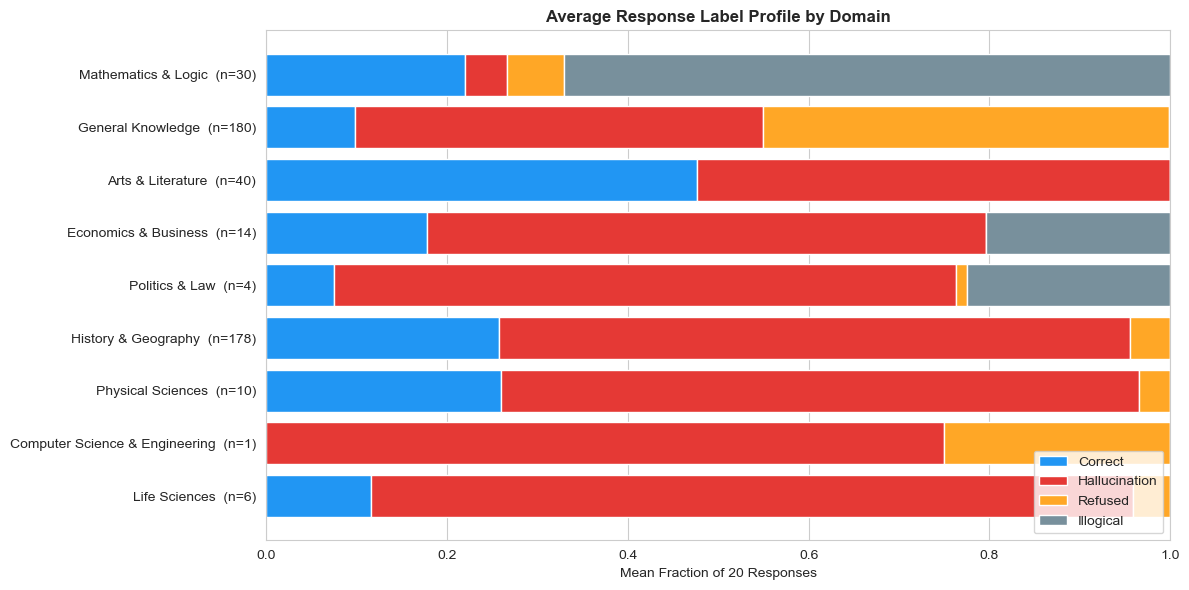

In [52]:
# stacked bar: mean label fractions per domain (question-level)
# annotated with surviving question count

fig, ax = plt.subplots(figsize=(12, 6))
frac_labels = ['frac_correct', 'frac_hallu', 'frac_refused', 'frac_illogical']
frac_nice = ['Correct', 'Hallucination', 'Refused', 'Illogical']
frac_colors = [LABEL_COLORS['correct'], LABEL_COLORS['hallucination'],
               LABEL_COLORS['refused'], LABEL_COLORS['illogical']]

df_plot = domain_fracs.reset_index()
# annotate y-axis labels with question count
y_labels = [
    f'{dom}  (n={survived_counts[dom]})'
    for dom in df_plot['domain']
]
bottom = np.zeros(len(df_plot))
for col, nice, color in zip(frac_labels, frac_nice, frac_colors):
    vals = df_plot[col].values
    ax.barh(y_labels, vals, left=bottom, color=color, label=nice)
    bottom += vals

ax.set_xlabel('Mean Fraction of 20 Responses')
ax.set_title('Average Response Label Profile by Domain', fontweight='bold')
ax.legend(loc='lower right')
ax.set_xlim(0, 1)
plt.tight_layout()
# plt.savefig(os.path.join(OUTPUT_DIR, 'fig03_question_label_profiles.png'), dpi=150, bbox_inches='tight')
plt.show()

In [53]:
# compare naive vs strict hallucination rate by domain
# naive = 1 - (n_correct/20), strict = n_hallu / (n_correct + n_hallu)

rate_compare = feat_df.groupby('domain').agg(
    naive_rate=('hall_rate_naive', 'mean'),
    strict_rate=('hall_rate_strict', 'mean'),
    mean_refused=('frac_refused', 'mean'),
    mean_illogical=('frac_illogical', 'mean'),
    n_questions=('label', 'count'),
).sort_values('naive_rate', ascending=False)
rate_compare['gap'] = rate_compare['naive_rate'] - rate_compare['strict_rate']
print('Naive vs strict hallucination rate by domain:')
print('(gap = inflation from refused + illogical responses)')
display(rate_compare.round(3))

Naive vs strict hallucination rate by domain:
(gap = inflation from refused + illogical responses)


,naive_rate,strict_rate,mean_refused,mean_illogical,n_questions,gap
domain,,,,,,
Computer Science & Engineering,1.000,1.000,0.250,0.000,1,0.000
Politics & Law,0.925,0.688,0.012,0.225,4,0.238
General Knowledge,0.901,0.895,0.449,0.001,180,0.006
Life Sciences,0.883,0.872,0.042,0.000,6,0.012
Economics & Business,0.821,0.754,0.000,0.204,14,0.068
Mathematics & Logic,0.780,0.309,0.063,0.670,30,0.471
History & Geography,0.743,0.740,0.045,0.000,178,0.003
Physical Sciences,0.740,0.739,0.035,0.000,10,0.001
Arts & Literature,0.524,0.524,0.000,0.000,40,0.000


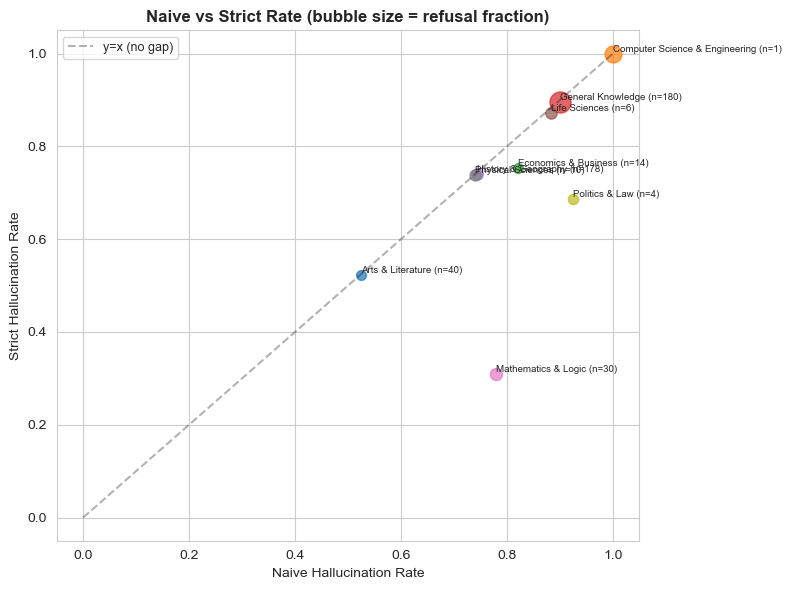

In [54]:
# scatter: naive vs strict rate, sized by refusal fraction

fig, ax = plt.subplots(figsize=(8, 6))
for dom in all_domains:
    row = rate_compare.loc[dom]
    size = 50 + 400 * row['mean_refused']
    ax.scatter(row['naive_rate'], row['strict_rate'], s=size, alpha=0.7)
    ax.annotate(f'{dom} (n={int(row["n_questions"])})', (row['naive_rate'], row['strict_rate']),
                fontsize=7, ha='left', va='bottom')
ax.plot([0, 1], [0, 1], 'k--', alpha=0.3, label='y=x (no gap)')
ax.set_xlabel('Naive Hallucination Rate')
ax.set_ylabel('Strict Hallucination Rate')
ax.set_title('Naive vs Strict Rate (bubble size = refusal fraction)', fontweight='bold')
ax.legend(fontsize=9)
plt.tight_layout()
# plt.savefig(os.path.join(OUTPUT_DIR, 'fig03b_naive_vs_strict.png'), dpi=150, bbox_inches='tight')
plt.show()

### Distribution of Refusal and Illogical Rates

If refusals and illogical outputs are concentrated in a few questions rather than
spread evenly, these histograms will show a spike at zero with a long right tail.

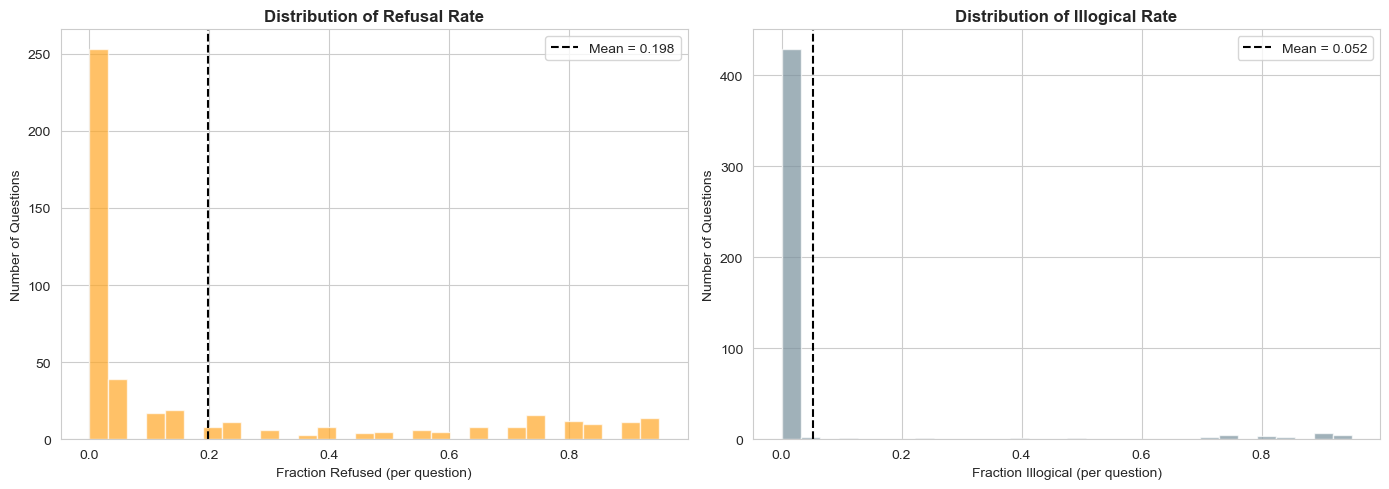

In [55]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(feat_df['frac_refused'], bins=30, color=LABEL_COLORS['refused'],
             alpha=0.7, edgecolor='white')
axes[0].set_xlabel('Fraction Refused (per question)')
axes[0].set_ylabel('Number of Questions')
axes[0].set_title('Distribution of Refusal Rate', fontweight='bold')
axes[0].axvline(feat_df['frac_refused'].mean(), color='black', linestyle='--',
                label=f'Mean = {feat_df["frac_refused"].mean():.3f}')
axes[0].legend()

axes[1].hist(feat_df['frac_illogical'], bins=30, color=LABEL_COLORS['illogical'],
             alpha=0.7, edgecolor='white')
axes[1].set_xlabel('Fraction Illogical (per question)')
axes[1].set_ylabel('Number of Questions')
axes[1].set_title('Distribution of Illogical Rate', fontweight='bold')
axes[1].axvline(feat_df['frac_illogical'].mean(), color='black', linestyle='--',
                label=f'Mean = {feat_df["frac_illogical"].mean():.3f}')
axes[1].legend()

plt.tight_layout()
# plt.savefig(os.path.join(OUTPUT_DIR, 'fig04_refused_illogical_dist.png'), dpi=150, bbox_inches='tight')
plt.show()

## Geometric Feature Distributions

Now we look at the 5 embedding-geometry features, split by the binary label.

In [56]:
for lab, tag in [(0, 'Correct'), (1, 'Hallucinated')]:
    sub = feat_df[feat_df['label'] == lab]
    print(f'--- {tag} (n={len(sub)}) ---')
    print(sub[GEO_FEATURES].describe().round(4).to_string())
    print()

--- Correct (n=109) ---
          H_sem     D_cos     M_bar         K    sig2_S
count  109.0000  109.0000  109.0000  109.0000  109.0000
mean     1.2993    0.1126   22.1532    4.9450    0.0443
std      1.1702    0.1019   14.5239    4.0821    0.0420
min     -0.0000   -0.0000    5.0346    1.0000    0.0000
25%      0.2864    0.0157    9.7396    2.0000    0.0048
50%      1.1540    0.0844   18.9955    3.0000    0.0398
75%      2.1710    0.1955   29.6566    7.0000    0.0739
max      4.1219    0.3528   65.8750   18.0000    0.1758

--- Hallucinated (n=354) ---
          H_sem     D_cos     M_bar         K    sig2_S
count  354.0000  354.0000  354.0000  354.0000  354.0000
mean     3.0124    0.3127   56.3536   11.8898    0.0548
std      1.1030    0.1285   19.2899    5.1770    0.0308
min     -0.0000   -0.0000    6.7511    1.0000    0.0000
25%      2.4278    0.2288   42.8365    8.0000    0.0336
50%      3.3414    0.3419   58.7188   13.0000    0.0490
75%      3.8842    0.4131   72.4987   16.0000    0

In [57]:
# hallucination rate summary by domain (using strict rate)

domain_stats = (
    feat_df.groupby('domain')
    .agg(
        n_questions=('label', 'count'),
        n_hallucinated=('label', 'sum'),
        hall_rate_mean=('hall_rate_strict', 'mean'),
        hall_rate_std=('hall_rate_strict', 'std'),
        mean_entropy=('H_sem', 'mean'),
        mean_refused=('frac_refused', 'mean'),
        mean_illogical=('frac_illogical', 'mean'),
    )
    .sort_values('hall_rate_mean', ascending=False)
)
domain_stats['pct_hallucinated'] = (
    domain_stats['n_hallucinated'] / domain_stats['n_questions'] * 100
).round(1)
domain_stats['in_analysis'] = [
    dom in analysis_domains for dom in domain_stats.index
]
display(domain_stats.round(3))
domain_stats.to_csv(os.path.join(OUTPUT_DIR, 'domain_stats.csv'))

,n_questions,n_hallucinated,hall_rate_mean,hall_rate_std,mean_entropy,mean_refused,mean_illogical,pct_hallucinated,in_analysis
domain,,,,,,,,,
Computer Science & Engineering,1,1,1.000,NaN,4.122,0.250,0.000,100.0,False
General Knowledge,180,163,0.895,0.244,3.251,0.449,0.001,90.6,True
Life Sciences,6,6,0.872,0.194,3.602,0.042,0.000,100.0,False
Economics & Business,14,11,0.754,0.351,2.897,0.000,0.204,78.6,True
History & Geography,178,132,0.740,0.344,2.159,0.045,0.000,74.2,True
Physical Sciences,10,7,0.739,0.364,3.161,0.035,0.000,70.0,True
Politics & Law,4,3,0.688,0.466,2.334,0.012,0.225,75.0,False
Arts & Literature,40,22,0.524,0.436,1.061,0.000,0.000,55.0,True
Mathematics & Logic,30,9,0.309,0.433,2.960,0.063,0.670,30.0,True


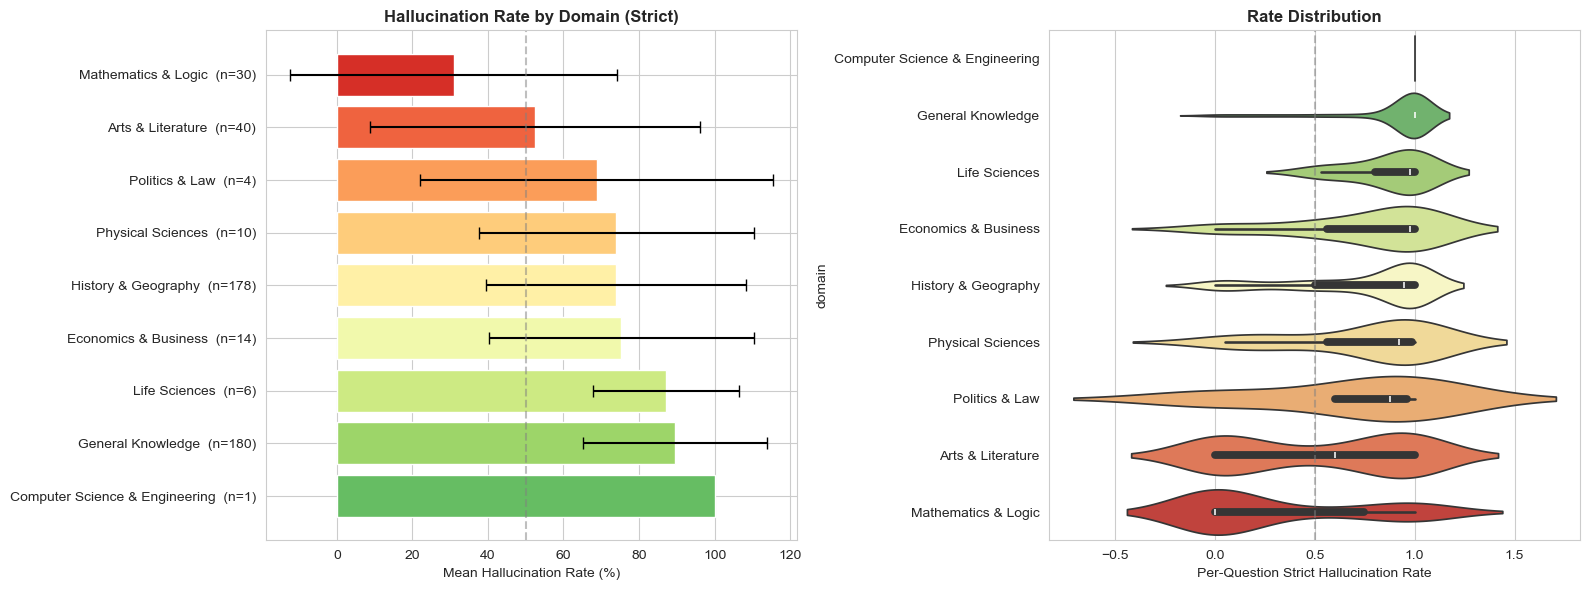

In [58]:
# hallucination rate bar + violin

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

ds = domain_stats.reset_index()
y_labels_ds = [
    f'{row["domain"]}  (n={int(row["n_questions"])})'
    for _, row in ds.iterrows()
]
colors = plt.cm.RdYlGn_r(np.linspace(0.2, 0.9, len(ds)))
axes[0].barh(y_labels_ds, ds['hall_rate_mean'] * 100,
             xerr=ds['hall_rate_std'] * 100,
             color=colors, capsize=4)
axes[0].set_xlabel('Mean Hallucination Rate (%)')
axes[0].set_title('Hallucination Rate by Domain (Strict)', fontweight='bold')
axes[0].axvline(50, color='gray', linestyle='--', alpha=0.5)

# violin (all domains)
order = ds['domain'].tolist()
sns.violinplot(data=feat_df, y='domain', x='hall_rate_strict',
               order=order, orient='h', palette='RdYlGn_r',
               ax=axes[1], inner='box')
axes[1].set_xlabel('Per-Question Strict Hallucination Rate')
axes[1].set_title('Rate Distribution', fontweight='bold')
axes[1].axvline(0.5, color='gray', linestyle='--', alpha=0.5)

plt.tight_layout()
# plt.savefig(os.path.join(OUTPUT_DIR, 'fig05_hallu_rate_by_domain.png'), dpi=150, bbox_inches='tight')
plt.show()

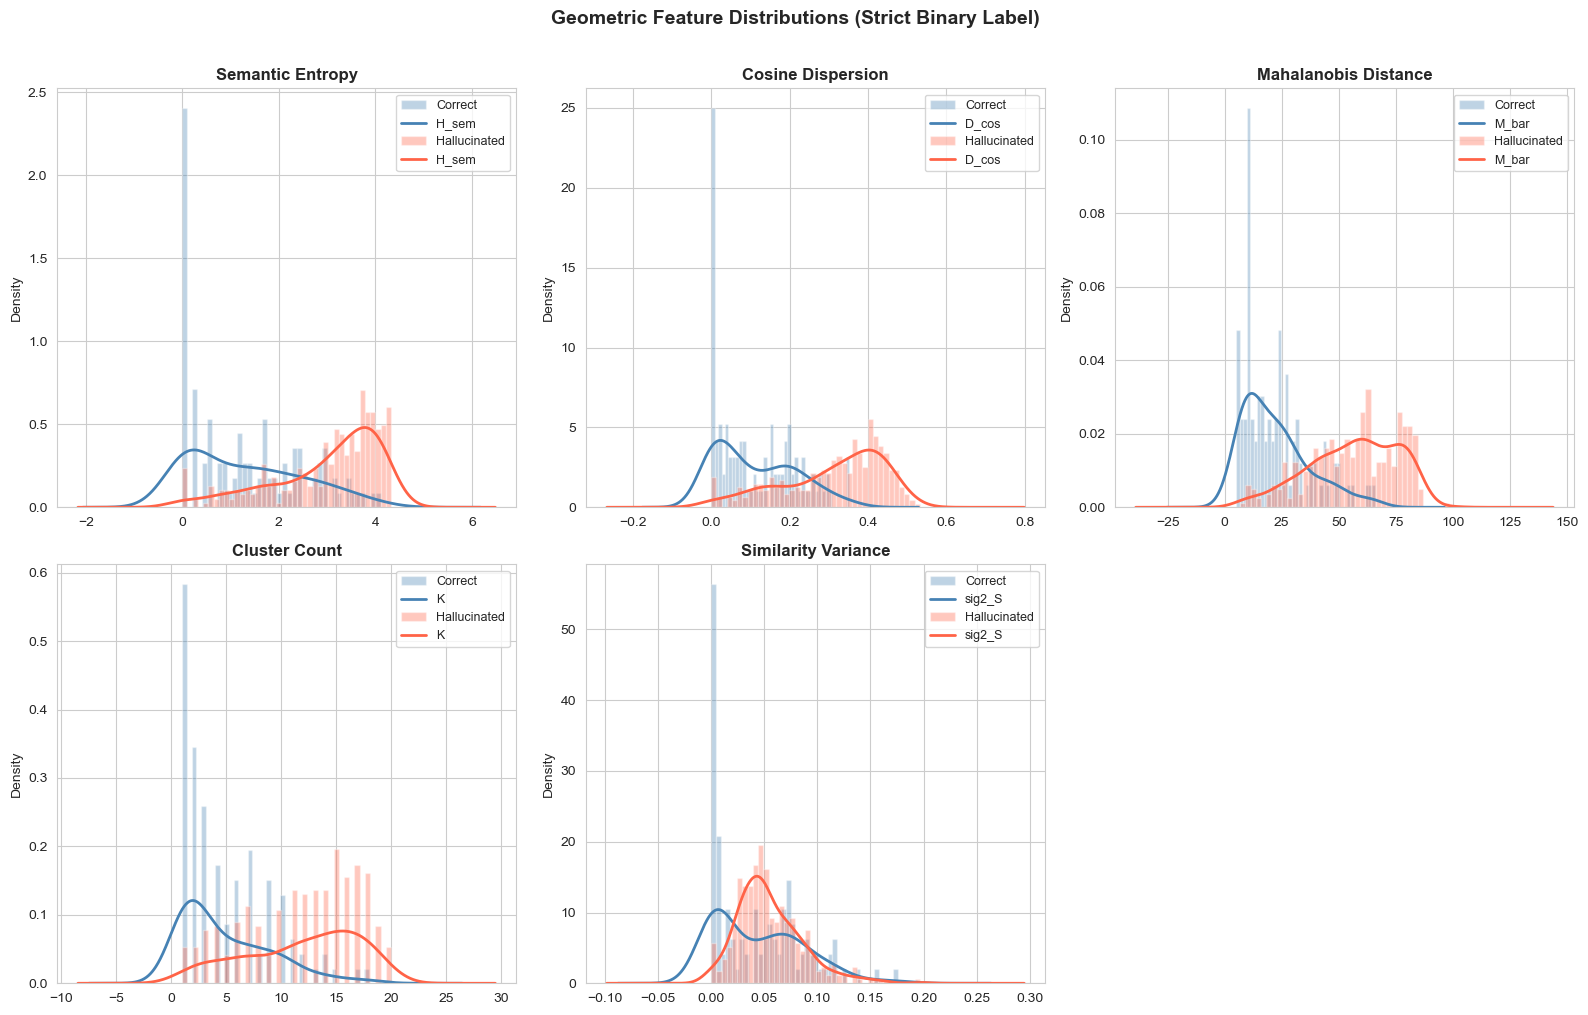

In [59]:
# KDE plots for each geometric feature, correct vs hallucinated

FEAT_LABELS = {
    'H_sem':  'Semantic Entropy',
    'D_cos':  'Cosine Dispersion',
    'M_bar':  'Mahalanobis Distance',
    'K':      'Cluster Count',
    'sig2_S': 'Similarity Variance',
}

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, (feat, nice) in enumerate(FEAT_LABELS.items()):
    ax = axes[i]
    for lab, color, lbl in [(0, 'steelblue', 'Correct'), (1, 'tomato', 'Hallucinated')]:
        vals = feat_df.loc[feat_df['label'] == lab, feat]
        ax.hist(vals, bins=40, alpha=0.35, color=color, density=True, label=lbl)
        if len(vals) > 2:
            try:
                vals.plot.kde(ax=ax, color=color, linewidth=2)
            except Exception:
                pass
    ax.set_title(nice, fontweight='bold')
    ax.set_ylabel('Density')
    ax.legend(fontsize=9)

axes[-1].axis('off')
plt.suptitle('Geometric Feature Distributions (Strict Binary Label)',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
# plt.savefig(os.path.join(OUTPUT_DIR, 'fig06_kde_features.png'), dpi=150, bbox_inches='tight')
plt.show()

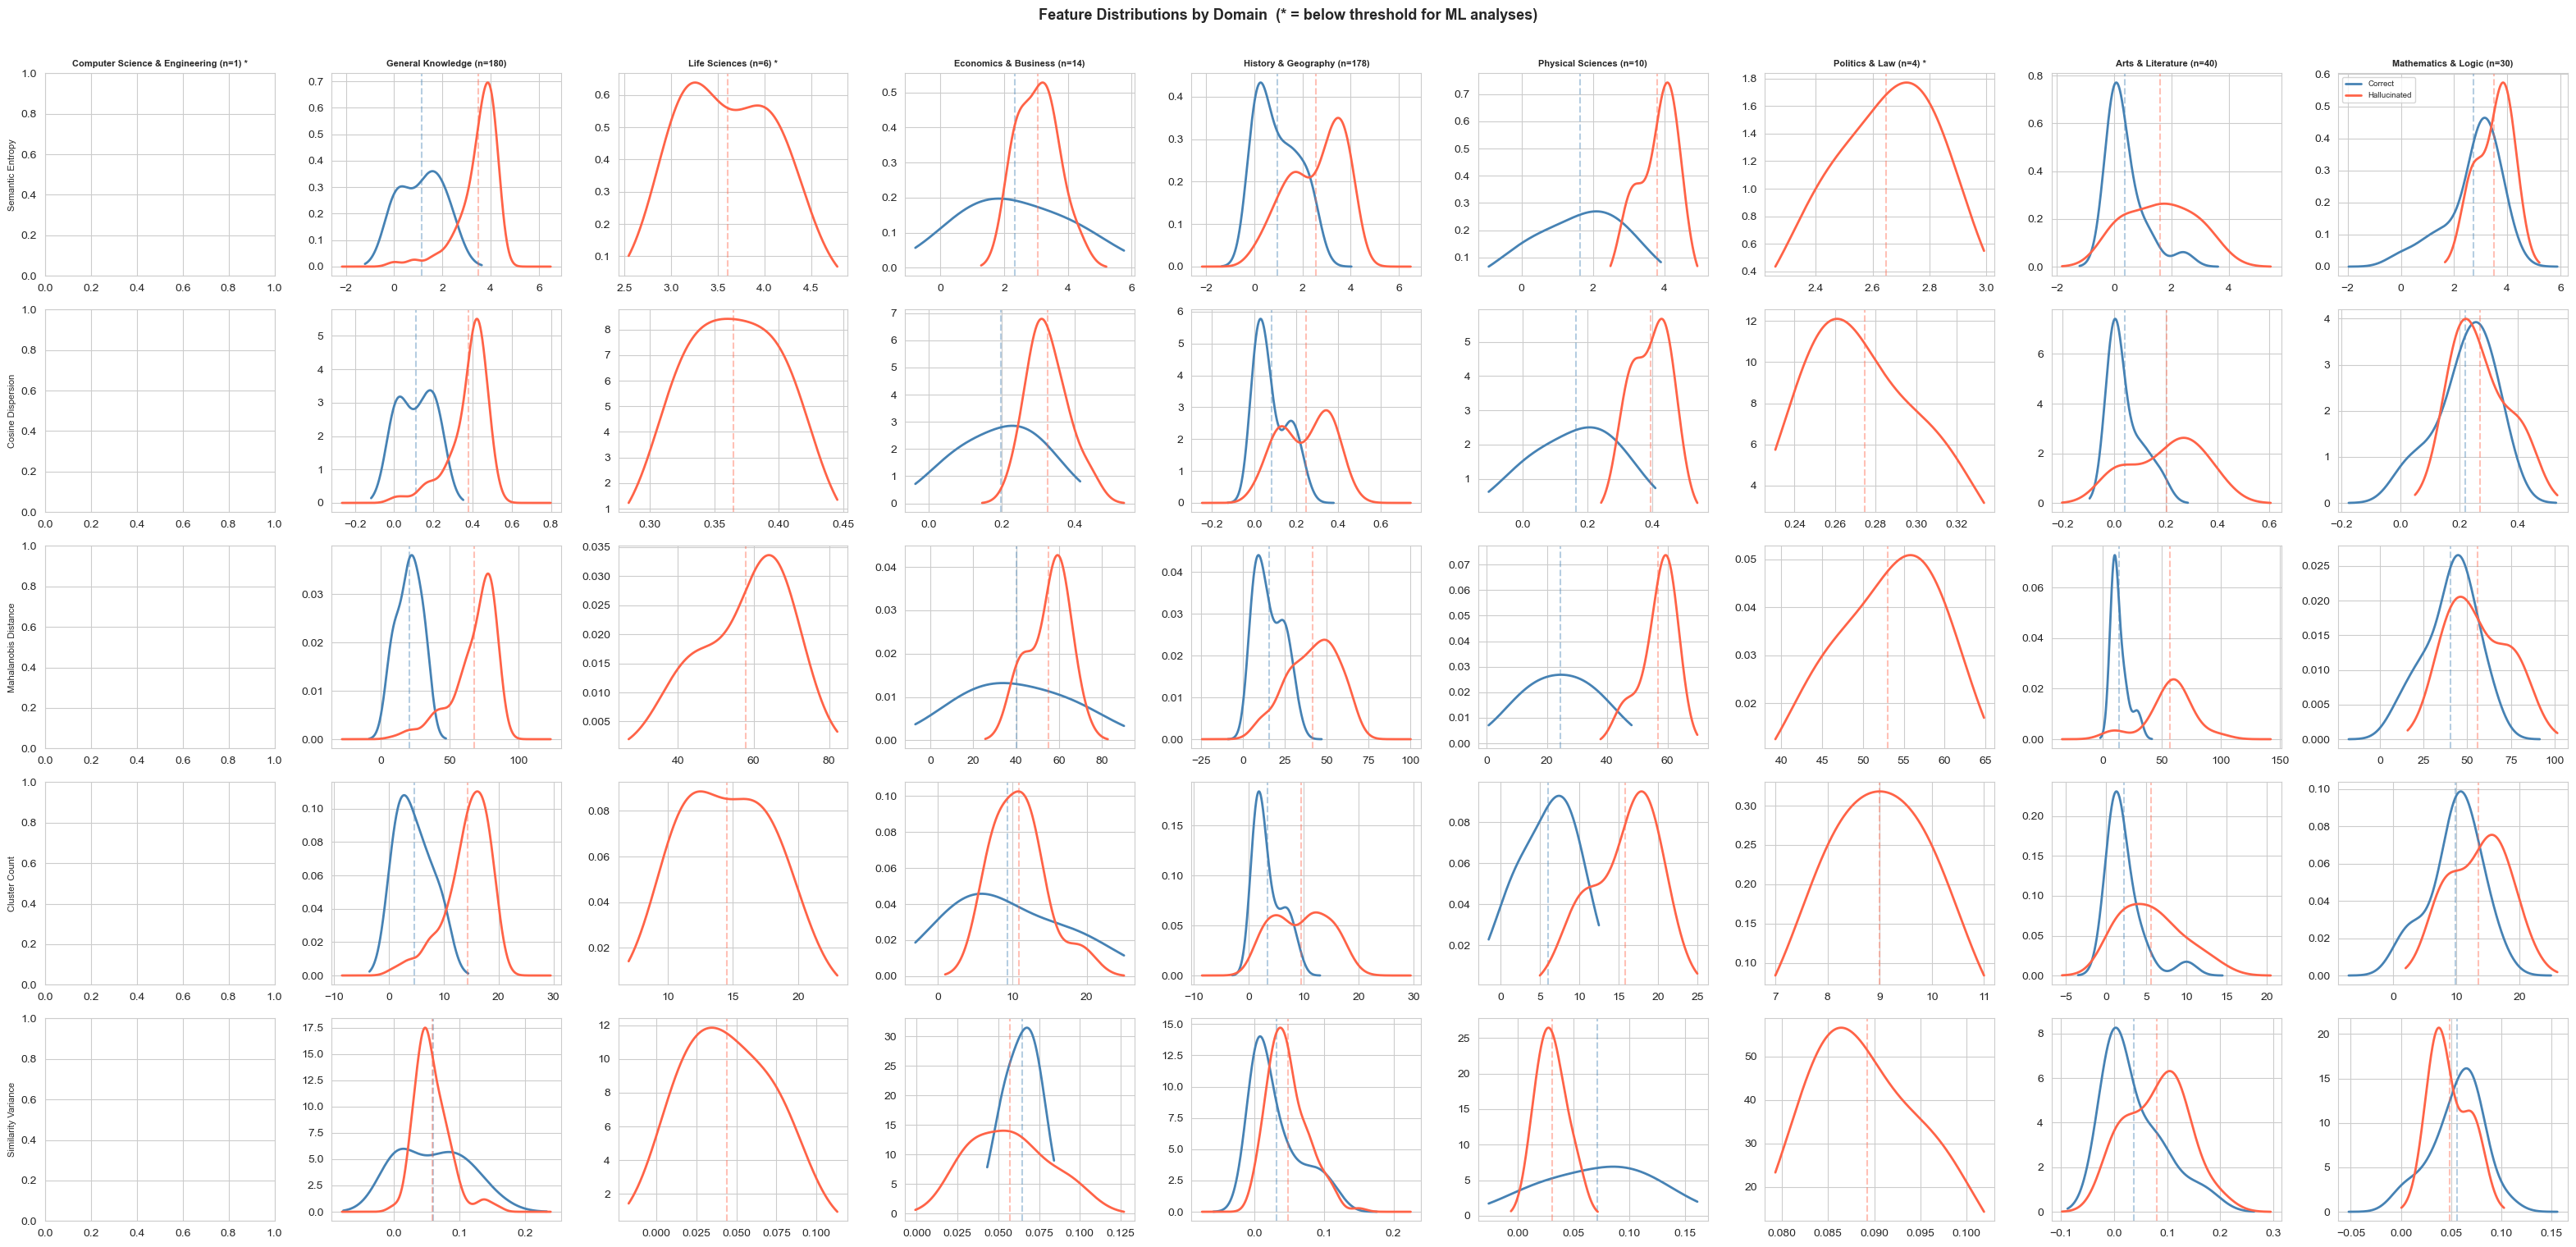

In [60]:
# per-domain feature KDEs (all domains for EDA, but flag small ones)

domains_ordered = domain_stats.reset_index()['domain'].tolist()
n_domains = len(domains_ordered)

fig, axes = plt.subplots(
    len(FEAT_LABELS), n_domains,
    figsize=(3.5 * n_domains, 3 * len(FEAT_LABELS)),
    sharey=False
)
if n_domains == 1:
    axes = axes.reshape(-1, 1)

for row, (feat, nice) in enumerate(FEAT_LABELS.items()):
    for col, dom in enumerate(domains_ordered):
        ax = axes[row][col]
        sub = feat_df[feat_df['domain'] == dom]
        n_dom = len(sub)
        for lab, color, name in [(0, 'steelblue', 'Correct'), (1, 'tomato', 'Hallucinated')]:
            vals = sub[sub['label'] == lab][feat]
            if len(vals) > 2:
                try:
                    vals.plot.kde(ax=ax, color=color, label=name, linewidth=2)
                except Exception:
                    pass
                ax.axvline(vals.mean(), color=color, linestyle='--', alpha=0.4)
        if row == 0:
            title = f'{dom} (n={n_dom})'
            if dom not in analysis_domains:
                title += ' *'
            ax.set_title(title, fontweight='bold', fontsize=8)
        ax.set_ylabel(nice if col == 0 else '', fontsize=8)
        ax.set_xlabel('')
        if row == 0 and col == n_domains - 1:
            ax.legend(fontsize=7)

plt.suptitle('Feature Distributions by Domain  (* = below threshold for ML analyses)',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
# plt.savefig(os.path.join(OUTPUT_DIR, 'fig07_kde_by_domain.png'), dpi=120, bbox_inches='tight')
plt.show()

### Correlation Analysis

We check correlations among the 5 geometric features and also include the refusal and
illogical fractions plus the strict hallucination rate. High correlation between entropy
and dispersion is expected; the question is how much redundancy there is.

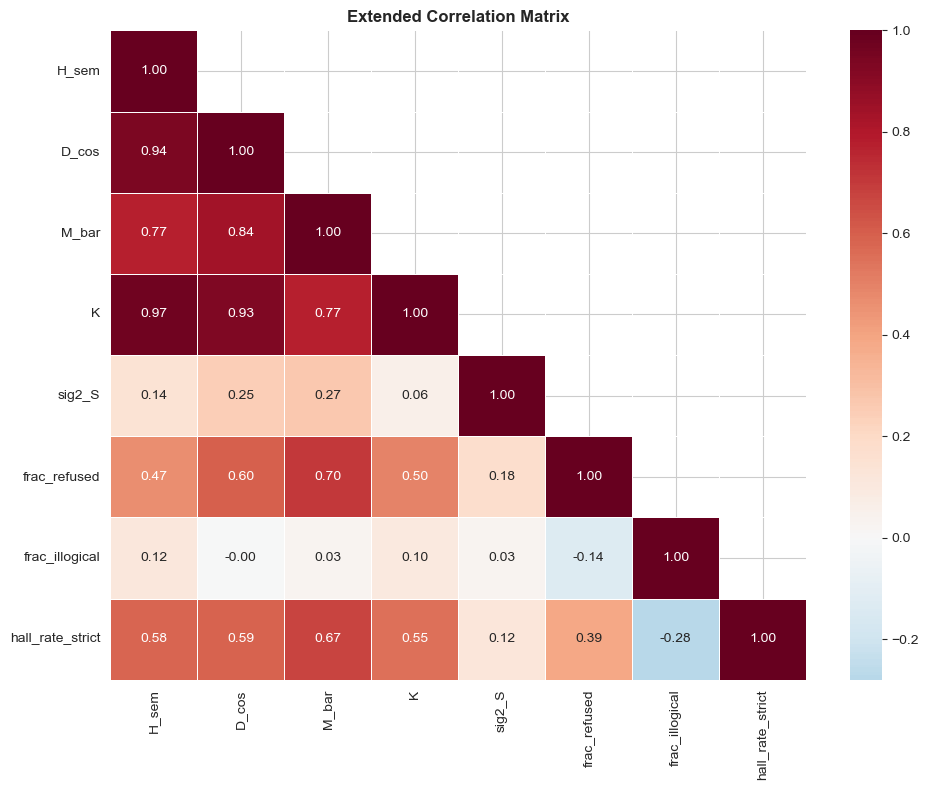

In [61]:
# extended correlation: geometric features + label fractions
corr_cols = GEO_FEATURES + ['frac_refused', 'frac_illogical', 'hall_rate_strict']
corr = feat_df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            ax=ax, mask=mask, linewidths=0.5)
ax.set_title('Extended Correlation Matrix', fontweight='bold')
plt.tight_layout()
# plt.savefig(os.path.join(OUTPUT_DIR, 'fig08_correlation.png'), dpi=150, bbox_inches='tight')
plt.show()

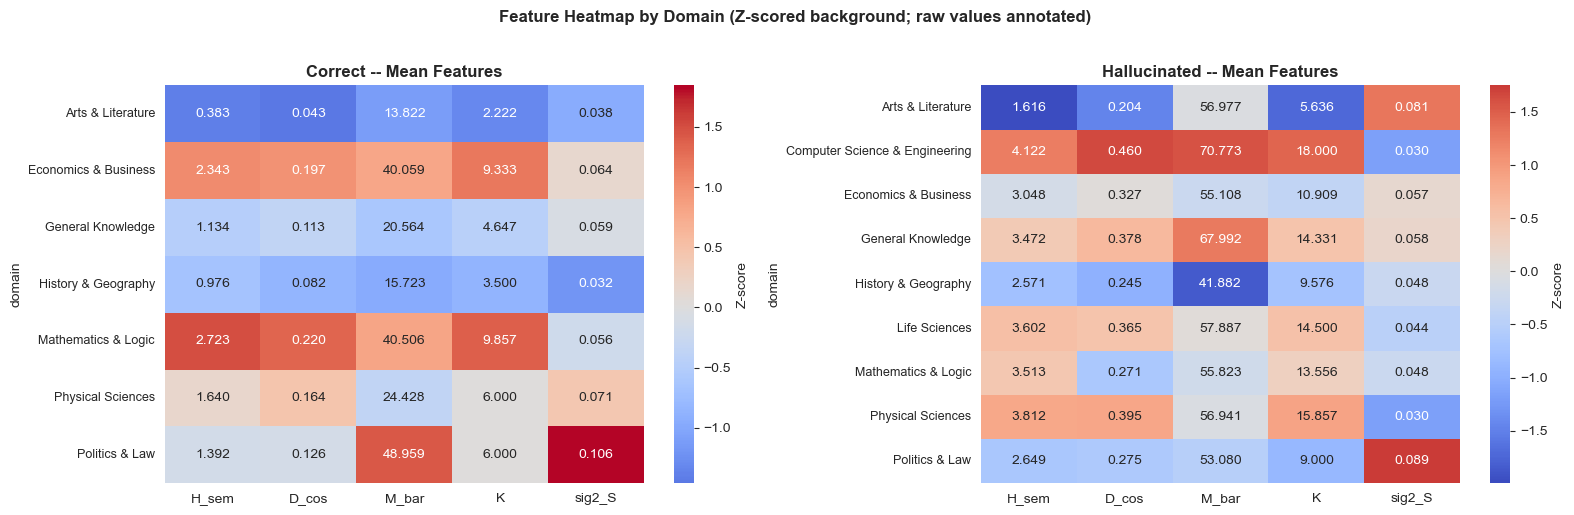

In [62]:
# z-scored feature heatmaps by domain, split by label

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
for ax_idx, (lbl_val, split_name) in enumerate([(0, 'Correct'), (1, 'Hallucinated')]):
    hm_data = feat_df[feat_df['label'] == lbl_val].groupby('domain')[GEO_FEATURES].mean()
    hm_norm = (hm_data - hm_data.mean()) / (hm_data.std() + 1e-9)
    sns.heatmap(hm_norm, annot=hm_data.round(3), fmt='.3f',
                cmap='coolwarm', center=0, ax=axes[ax_idx],
                cbar_kws={'label': 'Z-score'})
    axes[ax_idx].set_title(f'{split_name} -- Mean Features', fontweight='bold')
    axes[ax_idx].tick_params(axis='y', labelsize=9)
plt.suptitle('Feature Heatmap by Domain (Z-scored background; raw values annotated)',
             fontweight='bold', y=1.02)
plt.tight_layout()
# plt.savefig(os.path.join(OUTPUT_DIR, 'fig09_domain_heatmaps.png'), dpi=150, bbox_inches='tight')
plt.show()

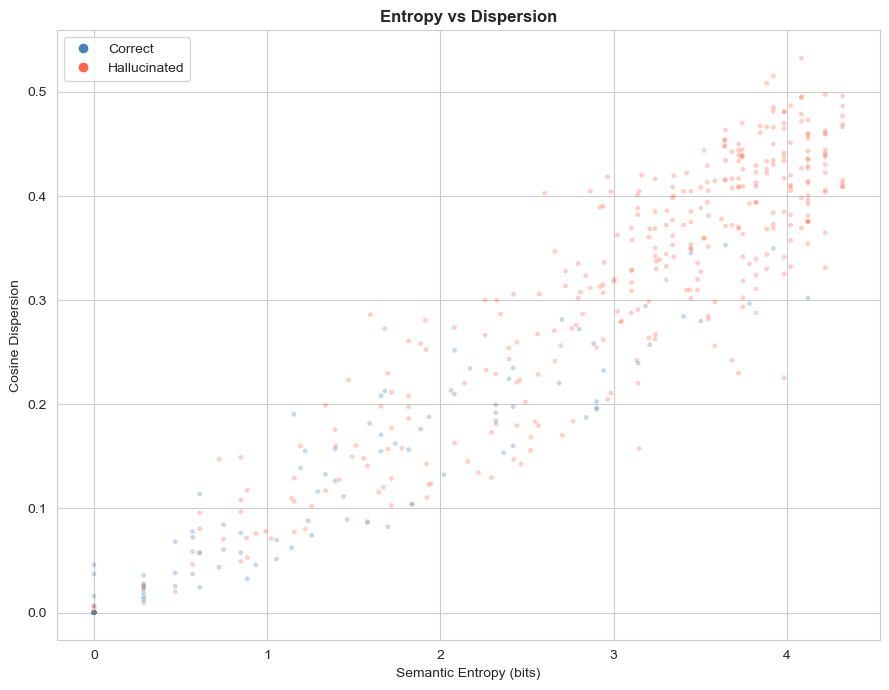

In [63]:
# scatter: entropy vs dispersion, colored by label

fig, ax = plt.subplots(figsize=(9, 7))
colors = feat_df['label'].map({0: 'steelblue', 1: 'tomato'})
ax.scatter(feat_df['H_sem'], feat_df['D_cos'], c=colors, alpha=0.3, s=12, edgecolors='none')
ax.set_xlabel('Semantic Entropy (bits)')
ax.set_ylabel('Cosine Dispersion')
ax.set_title('Entropy vs Dispersion', fontweight='bold')
legend_elems = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='steelblue', markersize=8, label='Correct'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='tomato', markersize=8, label='Hallucinated'),
]
ax.legend(handles=legend_elems)
plt.tight_layout()
# plt.savefig(os.path.join(OUTPUT_DIR, 'fig10_entropy_vs_dispersion.png'), dpi=150, bbox_inches='tight')
plt.show()

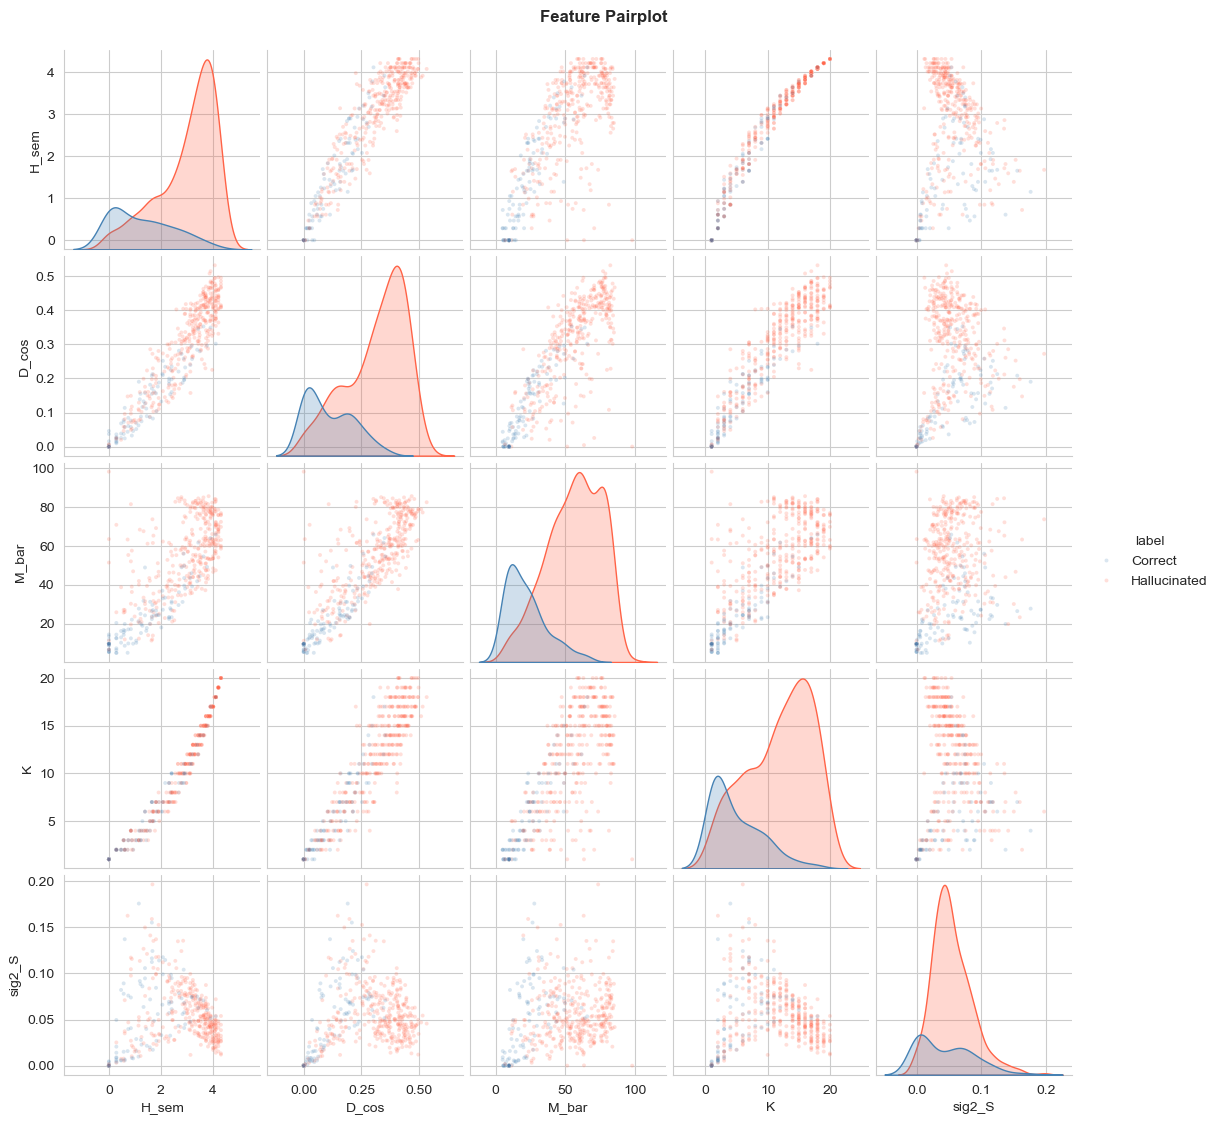

In [64]:
# pairplot

plot_df = feat_df[GEO_FEATURES + ['label']].copy()
plot_df['label'] = plot_df['label'].map({0: 'Correct', 1: 'Hallucinated'})
g = sns.pairplot(plot_df, hue='label',
                 palette={'Correct': 'steelblue', 'Hallucinated': 'tomato'},
                 diag_kind='kde', plot_kws={'alpha': 0.2, 's': 8}, height=2.2)
g.fig.suptitle('Feature Pairplot', y=1.02, fontweight='bold')
g.savefig(os.path.join(OUTPUT_DIR, 'fig11_pairplot.png'), dpi=100, bbox_inches='tight')
plt.show()

## Statistical Tests

### KS Tests -- Global and Per-Domain

Two-sample Kolmogorov-Smirnov tests for each geometric feature. The KS statistic
measures the maximum gap between the empirical CDFs of the two groups; a large D means
the feature distributions are well-separated. Per-domain tests use Bonferroni correction.

In [65]:
# global KS
print('Global KS tests (Bonferroni alpha = 0.01):')
ks_global = []
for feat in GEO_FEATURES:
    g0 = feat_df.loc[feat_df['label'] == 0, feat].values
    g1 = feat_df.loc[feat_df['label'] == 1, feat].values
    if len(g0) < 2 or len(g1) < 2:
        continue
    stat, p = ks_2samp(g0, g1)
    sig = '***' if p < 0.001 else ('**' if p < 0.01 else ('*' if p < 0.05 else 'ns'))
    ks_global.append({'Feature': feat, 'KS_stat': stat, 'p_value': p, 'sig': sig})
    print(f'  {feat:10s}  D={stat:.4f}  p={p:.2e}  {sig}')

pd.DataFrame(ks_global).to_csv(os.path.join(OUTPUT_DIR, 'ks_tests_global.csv'), index=False)

Global KS tests (Bonferroni alpha = 0.01):
  H_sem       D=0.5799  p=1.15e-26  ***
  D_cos       D=0.6201  p=9.50e-31  ***
  M_bar       D=0.6957  p=1.14e-39  ***
  K           D=0.5460  p=1.81e-23  ***
  sig2_S      D=0.3387  p=5.13e-09  ***


In [66]:
# per-domain KS (all domains for completeness, but flag small ones)
n_tests = len(GEO_FEATURES) * len(all_domains)
alpha_bonf = 0.05 / n_tests
print(f'Tests: {n_tests}, Bonferroni alpha: {alpha_bonf:.6f}')

ks_rows = []
for dom in all_domains:
    df_d = feat_df[feat_df['domain'] == dom]
    for feat in GEO_FEATURES:
        g0 = df_d[df_d['label'] == 0][feat].values
        g1 = df_d[df_d['label'] == 1][feat].values
        if len(g0) < 2 or len(g1) < 2:
            continue
        stat, p = ks_2samp(g0, g1)
        ks_rows.append({
            'Domain': dom, 'Feature': feat,
            'KS_stat': round(stat, 4), 'p_value': p,
            'Significant': p < alpha_bonf,
            'n_questions': len(df_d),
        })

df_ks = pd.DataFrame(ks_rows)
df_ks.to_csv(os.path.join(OUTPUT_DIR, 'ks_tests_per_domain.csv'), index=False)
display(df_ks)

Tests: 45, Bonferroni alpha: 0.001111


,Domain,Feature,KS_stat,p_value,Significant,n_questions
0,Arts & Literature,H_sem,0.6061,6.484414e-04,True,40
1,Arts & Literature,D_cos,0.6364,2.452651e-04,True,40
2,Arts & Literature,M_bar,0.9091,3.704348e-09,True,40
3,Arts & Literature,K,0.5152,6.323544e-03,False,40
4,Arts & Literature,sig2_S,0.5101,6.655658e-03,False,40
5,Economics & Business,H_sem,0.6667,1.538462e-01,False,14
6,Economics & Business,D_cos,0.6667,1.538462e-01,False,14
7,Economics & Business,M_bar,0.6667,1.538462e-01,False,14
8,Economics & Business,K,0.6667,1.538462e-01,False,14
9,Economics & Business,sig2_S,0.3939,7.252747e-01,False,14


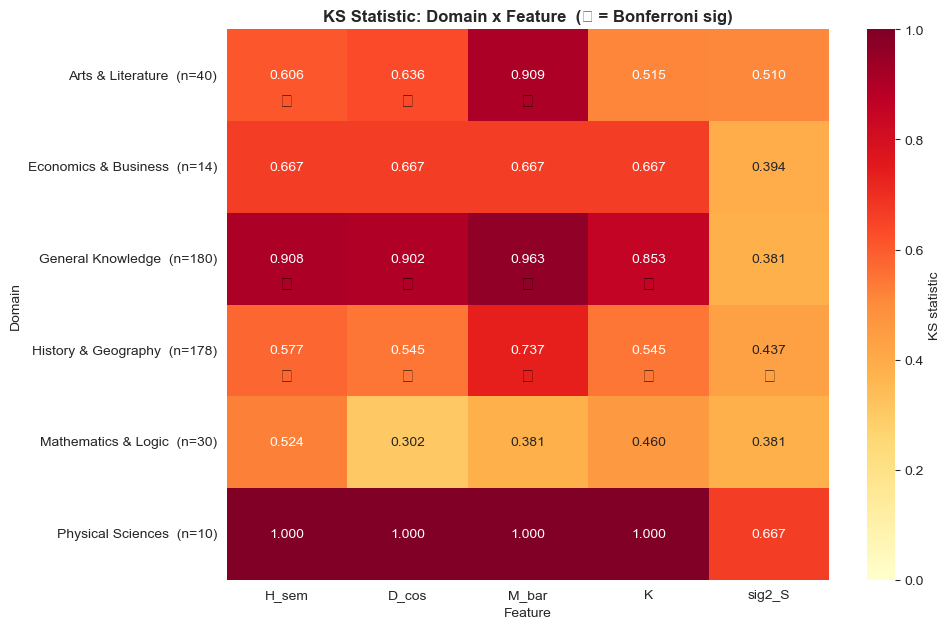

In [67]:
# KS heatmap

ks_pivot = df_ks.pivot(index='Domain', columns='Feature', values='KS_stat').fillna(0)
sig_pivot = df_ks.pivot(index='Domain', columns='Feature', values='Significant').fillna(False)
ks_pivot = ks_pivot.reindex(columns=GEO_FEATURES)
sig_pivot = sig_pivot.reindex(columns=GEO_FEATURES)

# annotate y-axis with question count
ks_y_labels = [
    f'{dom}  (n={survived_counts.get(dom, 0)})'
    for dom in ks_pivot.index
]

plt.figure(figsize=(10, max(4, len(all_domains) * 0.6 + 1)))
ax = sns.heatmap(ks_pivot, annot=True, fmt='.3f', cmap='YlOrRd',
                 vmin=0, vmax=1, yticklabels=ks_y_labels,
                 cbar_kws={'label': 'KS statistic'})
for i, dom in enumerate(ks_pivot.index):
    for j, feat in enumerate(ks_pivot.columns):
        if sig_pivot.loc[dom, feat]:
            ax.text(j + 0.5, i + 0.78, '\u2605', ha='center', va='center',
                    color='black', fontsize=13)
plt.title(f'KS Statistic: Domain x Feature  (\u2605 = Bonferroni sig)', fontweight='bold')
plt.tight_layout()
# plt.savefig(os.path.join(OUTPUT_DIR, 'fig12_ks_heatmap.png'), dpi=150, bbox_inches='tight')
plt.show()

### Permutation Test on Entropy Difference

Observed delta (hallu - correct): 1.7132 bits
Permutation p-value (10000 iters): 0.000000


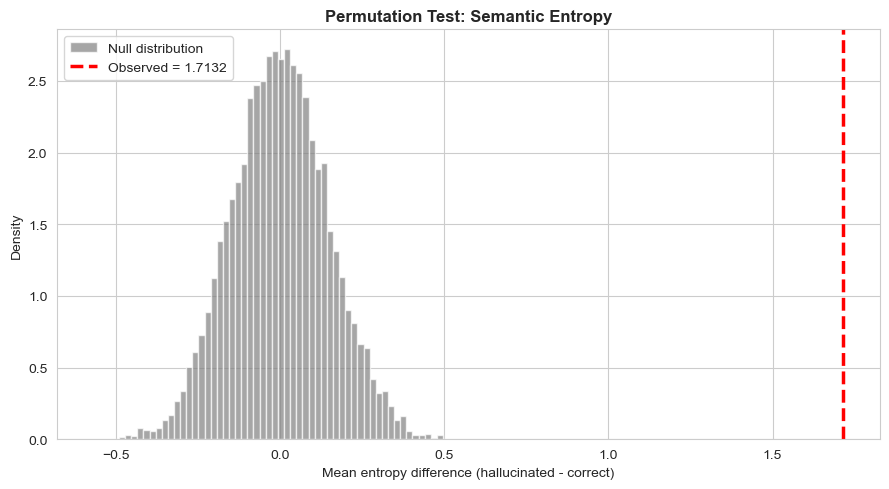

In [68]:
ent_correct = feat_df.loc[feat_df['label'] == 0, 'H_sem'].values
ent_hallu = feat_df.loc[feat_df['label'] == 1, 'H_sem'].values
delta_obs = ent_hallu.mean() - ent_correct.mean()
print(f'Observed delta (hallu - correct): {delta_obs:.4f} bits')

all_ent = feat_df['H_sem'].values
all_labels = feat_df['label'].values
rng = np.random.default_rng(RANDOM_SEED)

perm_deltas = np.zeros(N_PERMUTATIONS)
for p in range(N_PERMUTATIONS):
    shuffled = rng.permutation(all_labels)
    perm_deltas[p] = all_ent[shuffled == 1].mean() - all_ent[shuffled == 0].mean()

perm_pval = (perm_deltas >= delta_obs).sum() / N_PERMUTATIONS
print(f'Permutation p-value ({N_PERMUTATIONS} iters): {perm_pval:.6f}')

fig, ax = plt.subplots(figsize=(9, 5))
ax.hist(perm_deltas, bins=60, color='gray', alpha=0.7, density=True, label='Null distribution')
ax.axvline(delta_obs, color='red', linewidth=2.5, linestyle='--',
           label=f'Observed = {delta_obs:.4f}')
ax.set_xlabel('Mean entropy difference (hallucinated - correct)')
ax.set_ylabel('Density')
ax.set_title('Permutation Test: Semantic Entropy', fontweight='bold')
ax.legend()
plt.tight_layout()
# plt.savefig(os.path.join(OUTPUT_DIR, 'fig13_permutation_test.png'), dpi=150, bbox_inches='tight')
plt.show()

## Classification and Ablation

We run two sets of experiments:

1. Using only the 5 geometric features (the core pipeline).
2. Using the 5 geometric features + frac_refused + frac_illogical (extended set).

Ablation subsets test which features drive performance. Three classifiers
(Logistic Regression, Random Forest, XGBoost) are evaluated with 5-fold
stratified cross-validation.

In [69]:
# feature sets
EXTENDED_FEATURES = GEO_FEATURES + ['frac_refused', 'frac_illogical']

X_geo = feat_df[GEO_FEATURES].values
X_ext = feat_df[EXTENDED_FEATURES].values
y_all = feat_df['label'].values

scaler_geo = StandardScaler()
scaler_ext = StandardScaler()
X_geo_sc = scaler_geo.fit_transform(X_geo)
X_ext_sc = scaler_ext.fit_transform(X_ext)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)

classifiers = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=RANDOM_SEED),
    'Random Forest': RandomForestClassifier(n_estimators=200, max_depth=6, random_state=RANDOM_SEED),
    'XGBoost': xgb.XGBClassifier(
        n_estimators=200, max_depth=4, learning_rate=0.1,
        eval_metric='logloss', random_state=RANDOM_SEED, verbosity=0
    ),
}

In [70]:
# ablation: feature subsets

ablation_sets = {
    'Entropy only (H_sem)':        ('geo', [0]),
    'Geometry only (D_cos, M_bar)': ('geo', [1, 2]),
    'Entropy + Geometry':           ('geo', [0, 1, 2]),
    'All 5 geometric':              ('geo', [0, 1, 2, 3, 4]),
    'All 5 + refused + illogical':  ('ext', [0, 1, 2, 3, 4, 5, 6]),
}

clf_rows = []
for variant, (fset, feat_idx) in ablation_sets.items():
    X_use = X_geo_sc if fset == 'geo' else X_ext_sc
    X_sub = X_use[:, feat_idx]
    for clf_name, clf in classifiers.items():
        scores = cross_val_score(clf, X_sub, y_all, cv=cv, scoring='roc_auc')
        clf_rows.append({
            'Variant': variant, 'Classifier': clf_name,
            'AUC_mean': scores.mean(), 'AUC_std': scores.std(),
        })
        print(f'  {variant:35s} | {clf_name:22s} | AUC = {scores.mean():.4f} +/- {scores.std():.4f}')

df_clf = pd.DataFrame(clf_rows)
df_clf.to_csv(os.path.join(OUTPUT_DIR, 'classification_results.csv'), index=False)
print()
display(df_clf.pivot_table(index='Variant', columns='Classifier', values='AUC_mean').round(3))

  Entropy only (H_sem)                | Logistic Regression    | AUC = 0.8476 +/- 0.0228
  Entropy only (H_sem)                | Random Forest          | AUC = 0.7925 +/- 0.0393
  Entropy only (H_sem)                | XGBoost                | AUC = 0.7895 +/- 0.0422
  Geometry only (D_cos, M_bar)        | Logistic Regression    | AUC = 0.9068 +/- 0.0288
  Geometry only (D_cos, M_bar)        | Random Forest          | AUC = 0.9119 +/- 0.0235
  Geometry only (D_cos, M_bar)        | XGBoost                | AUC = 0.8971 +/- 0.0340
  Entropy + Geometry                  | Logistic Regression    | AUC = 0.9096 +/- 0.0273
  Entropy + Geometry                  | Random Forest          | AUC = 0.9099 +/- 0.0269
  Entropy + Geometry                  | XGBoost                | AUC = 0.8973 +/- 0.0364
  All 5 geometric                     | Logistic Regression    | AUC = 0.9189 +/- 0.0219
  All 5 geometric                     | Random Forest          | AUC = 0.9139 +/- 0.0256
  All 5 geometric    

Classifier,Logistic Regression,Random Forest,XGBoost
Variant,,,
All 5 + refused + illogical,0.953,0.952,0.945
All 5 geometric,0.919,0.914,0.907
Entropy + Geometry,0.910,0.910,0.897
Entropy only (H_sem),0.848,0.792,0.790
"Geometry only (D_cos, M_bar)",0.907,0.912,0.897


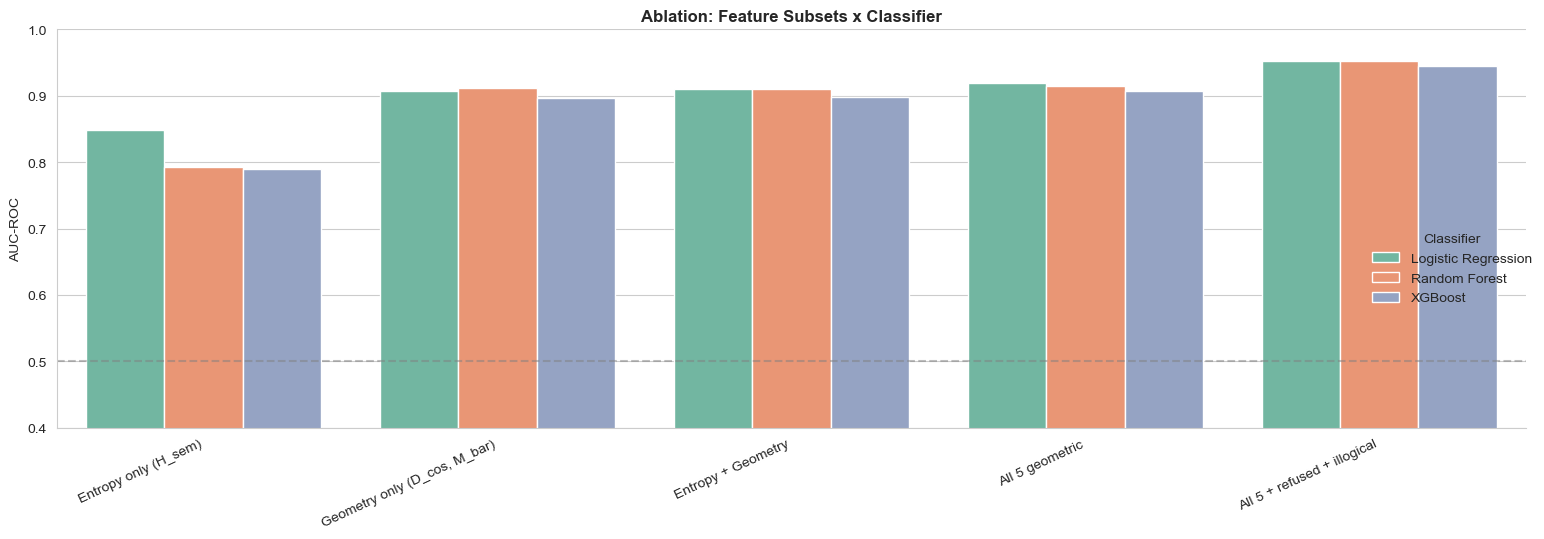

In [71]:
# ablation bar chart

g = sns.catplot(
    data=df_clf, kind='bar',
    x='Variant', y='AUC_mean', hue='Classifier',
    palette='Set2', height=5.5, aspect=2.5,
    capsize=0.05, errwidth=1.5,
)
g.ax.axhline(0.5, color='gray', linestyle='--', alpha=0.5)
g.ax.set_ylim(0.4, 1.0)
g.ax.set_title('Ablation: Feature Subsets x Classifier', fontweight='bold')
g.ax.set_ylabel('AUC-ROC')
g.ax.set_xlabel('')
plt.xticks(rotation=25, ha='right')
plt.tight_layout()
# plt.savefig(os.path.join(OUTPUT_DIR, 'fig14_ablation.png'), dpi=150, bbox_inches='tight')
plt.show()

### Per-Domain Classification

Only domains with at least MIN_QUESTIONS_FOR_ANALYSIS surviving questions are included.
Smaller domains produce unreliable AUC estimates due to insufficient fold sizes.

In [72]:
domain_clf_rows = []

for dom in analysis_domains:
    df_d = feat_df[feat_df['domain'] == dom]
    X_d = df_d[GEO_FEATURES].values
    y_d = df_d['label'].values
    if len(np.unique(y_d)) < 2:
        print(f'  Skipping {dom} (single class)')
        continue
    X_d_sc = StandardScaler().fit_transform(X_d)
    for clf_name, clf in classifiers.items():
        n_folds = min(5, min(Counter(y_d).values()))
        if n_folds < 2:
            continue
        cv_d = StratifiedKFold(n_splits=n_folds, shuffle=True, random_state=RANDOM_SEED)
        scores = cross_val_score(clf, X_d_sc, y_d, cv=cv_d, scoring='roc_auc')
        domain_clf_rows.append({
            'Domain': dom, 'Classifier': clf_name,
            'AUC_mean': scores.mean(), 'AUC_std': scores.std(),
            'n_questions': len(df_d),
        })

if excluded_domains:
    print(f'\nExcluded from per-domain classification (< {MIN_QUESTIONS_FOR_ANALYSIS} questions): {excluded_domains}')

df_dom_clf = pd.DataFrame(domain_clf_rows)
df_dom_clf.to_csv(os.path.join(OUTPUT_DIR, 'classification_per_domain.csv'), index=False)
display(df_dom_clf.pivot_table(index='Domain', columns='Classifier', values='AUC_mean').round(3))


Excluded from per-domain classification (< 10 questions): ['Computer Science & Engineering', 'Life Sciences', 'Politics & Law']


Classifier,Logistic Regression,Random Forest,XGBoost
Domain,,,
Arts & Literature,0.947,0.934,0.947
Economics & Business,0.667,0.611,0.500
General Knowledge,0.973,0.972,0.973
History & Geography,0.920,0.899,0.914
Mathematics & Logic,0.800,0.775,0.575
Physical Sciences,1.000,1.000,0.500


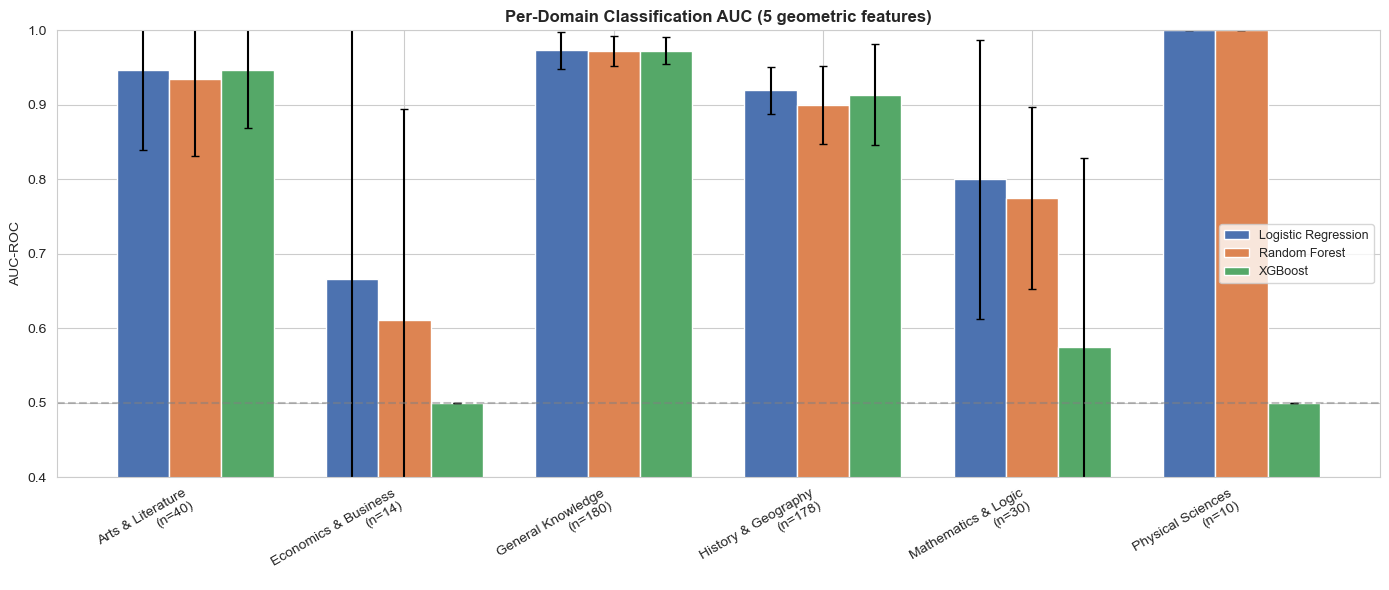

In [73]:
if len(df_dom_clf) > 0:
    pivot_dom = df_dom_clf.pivot_table(index='Domain', columns='Classifier', values='AUC_mean')
    dom_list = pivot_dom.index.tolist()
    x_pos = np.arange(len(dom_list))
    width = 0.25
    clf_names = list(classifiers.keys())
    colors_clf = ['#4C72B0', '#DD8452', '#55A868']

    fig, ax = plt.subplots(figsize=(14, 6))
    for i, (cname, color) in enumerate(zip(clf_names, colors_clf)):
        sub = df_dom_clf[df_dom_clf['Classifier'] == cname].set_index('Domain')
        aucs = sub.reindex(dom_list)['AUC_mean'].fillna(0)
        stds = sub.reindex(dom_list)['AUC_std'].fillna(0)
        ax.bar(x_pos + i * width, aucs, width, label=cname,
               color=color, yerr=stds, capsize=3)

    # x-axis labels with question count
    x_labels = [
        f'{dom}\n(n={survived_counts.get(dom, 0)})'
        for dom in dom_list
    ]
    ax.set_xticks(x_pos + width)
    ax.set_xticklabels(x_labels, rotation=30, ha='right')
    ax.set_ylabel('AUC-ROC')
    ax.set_ylim(0.4, 1.0)
    ax.axhline(0.5, color='gray', linestyle='--', alpha=0.5)
    ax.set_title('Per-Domain Classification AUC (5 geometric features)', fontweight='bold')
    ax.legend(fontsize=9)
    plt.tight_layout()
    # plt.savefig(os.path.join(OUTPUT_DIR, 'fig15_domain_classification.png'), dpi=150, bbox_inches='tight')
    plt.show()

### Bootstrap AUC Confidence Intervals

In [74]:
rng_boot = np.random.default_rng(RANDOM_SEED)

# global bootstrap
print('Global bootstrap (RF, 5 geometric features):')
auc_boot_global = []
for _ in range(N_BOOTSTRAP):
    idx = rng_boot.choice(len(y_all), len(y_all), replace=True)
    oob = np.setdiff1d(np.arange(len(y_all)), idx)
    if len(oob) < 10 or len(np.unique(y_all[oob])) < 2:
        continue
    rf_b = RandomForestClassifier(n_estimators=100, max_depth=6, random_state=0)
    rf_b.fit(X_geo_sc[idx], y_all[idx])
    proba = rf_b.predict_proba(X_geo_sc[oob])[:, 1]
    auc_boot_global.append(roc_auc_score(y_all[oob], proba))

auc_boot_global = np.array(auc_boot_global)
ci_lo, ci_hi = np.percentile(auc_boot_global, [2.5, 97.5])
print(f'  AUC = {auc_boot_global.mean():.4f}  95% CI [{ci_lo:.4f}, {ci_hi:.4f}]')
print()

# per-domain bootstrap (analysis_domains only)
boot_rows = []
print('Per-domain bootstrap:')
for dom in analysis_domains:
    df_d = feat_df[feat_df['domain'] == dom]
    X_d = StandardScaler().fit_transform(df_d[GEO_FEATURES].values)
    y_d = df_d['label'].values
    if len(np.unique(y_d)) < 2:
        continue
    auc_list = []
    for _ in range(N_BOOTSTRAP):
        idx = rng_boot.choice(len(y_d), len(y_d), replace=True)
        oob = np.setdiff1d(np.arange(len(y_d)), idx)
        if len(oob) < 5 or len(np.unique(y_d[oob])) < 2:
            continue
        rf_b = RandomForestClassifier(n_estimators=50, random_state=0)
        rf_b.fit(X_d[idx], y_d[idx])
        proba = rf_b.predict_proba(X_d[oob])[:, 1]
        auc_list.append(roc_auc_score(y_d[oob], proba))
    if len(auc_list) < 10:
        continue
    arr = np.array(auc_list)
    lo, hi = np.percentile(arr, [2.5, 97.5])
    boot_rows.append({'Domain': dom, 'AUC_mean': arr.mean(), 'CI_low': lo, 'CI_high': hi,
                      'n_questions': len(df_d)})
    print(f'  {dom:30s}  AUC={arr.mean():.3f}  [{lo:.3f}, {hi:.3f}]  (n={len(df_d)})')

if excluded_domains:
    print(f'\nExcluded: {excluded_domains}')

df_boot = pd.DataFrame(boot_rows).sort_values('AUC_mean', ascending=True)
df_boot.to_csv(os.path.join(OUTPUT_DIR, 'bootstrap_auc.csv'), index=False)

Global bootstrap (RF, 5 geometric features):
  AUC = 0.9037  95% CI [0.8567, 0.9442]

Per-domain bootstrap:
  Arts & Literature               AUC=0.925  [0.771, 1.000]  (n=40)


IndexError: index 1 is out of bounds for axis 1 with size 1

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].hist(auc_boot_global, bins=50, color='#1565C0', alpha=0.7, density=True)
axes[0].axvline(ci_lo, color='red', linestyle='--', label=f'2.5%={ci_lo:.3f}')
axes[0].axvline(ci_hi, color='red', linestyle='--', label=f'97.5%={ci_hi:.3f}')
axes[0].axvline(auc_boot_global.mean(), color='black', linewidth=2,
                label=f'Mean={auc_boot_global.mean():.3f}')
axes[0].set_xlabel('AUC-ROC')
axes[0].set_ylabel('Density')
axes[0].set_title('Bootstrap AUC (Global)', fontweight='bold')
axes[0].legend(fontsize=9)

if len(df_boot) > 0:
    y_pos = np.arange(len(df_boot))
    y_labels_boot = [
        f'{row["Domain"]}  (n={int(row["n_questions"])})'
        for _, row in df_boot.iterrows()
    ]
    axes[1].barh(y_pos, df_boot['AUC_mean'],
                 xerr=[df_boot['AUC_mean'] - df_boot['CI_low'],
                       df_boot['CI_high'] - df_boot['AUC_mean']],
                 capsize=5, color='steelblue', alpha=0.8)
    axes[1].set_yticks(y_pos)
    axes[1].set_yticklabels(y_labels_boot)
    axes[1].axvline(0.5, color='gray', linestyle='--', alpha=0.5)
    axes[1].set_xlabel('AUC-ROC')
    axes[1].set_title('Per-Domain Bootstrap AUC with 95% CI', fontweight='bold')

plt.tight_layout()
# plt.savefig(os.path.join(OUTPUT_DIR, 'fig16_bootstrap_auc.png'), dpi=150, bbox_inches='tight')
plt.show()

### ROC Curves

In [ ]:
# individual features vs combined

fig, ax = plt.subplots(figsize=(9, 7))
feat_colors = ['#E53935', '#1E88E5', '#43A047', '#FB8C00', '#8E24AA']

for i, (feat, color) in enumerate(zip(GEO_FEATURES, feat_colors)):
    vals = X_geo_sc[:, i]
    fpr, tpr, _ = roc_curve(y_all, vals)
    auc_s = roc_auc_score(y_all, vals)
    ax.plot(fpr, tpr, color=color, linewidth=1.5, alpha=0.8,
            label=f'{feat} (AUC={auc_s:.3f})')

# combined RF
rf_full = RandomForestClassifier(n_estimators=200, max_depth=6, random_state=RANDOM_SEED)
rf_full.fit(X_geo_sc, y_all)
y_scores = rf_full.predict_proba(X_geo_sc)[:, 1]
fpr_a, tpr_a, _ = roc_curve(y_all, y_scores)
auc_a = roc_auc_score(y_all, y_scores)
ax.plot(fpr_a, tpr_a, color='black', linewidth=2.5,
        label=f'All 5 - RF (AUC={auc_a:.3f})')

ax.plot([0, 1], [0, 1], 'k--', alpha=0.3)
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC: Individual Features vs Combined', fontweight='bold')
ax.legend(fontsize=9, loc='lower right')
plt.tight_layout()
# plt.savefig(os.path.join(OUTPUT_DIR, 'fig17_roc_features.png'), dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# per-domain ROC (analysis_domains only)

fig, ax = plt.subplots(figsize=(9, 7))
roc_colors = plt.cm.tab10(np.linspace(0, 1, len(analysis_domains)))
for color, dom in zip(roc_colors, analysis_domains):
    df_d = feat_df[feat_df['domain'] == dom]
    X_d = StandardScaler().fit_transform(df_d[GEO_FEATURES].values)
    y_d = df_d['label'].values
    if len(np.unique(y_d)) < 2:
        continue
    rf_d = RandomForestClassifier(n_estimators=200, random_state=RANDOM_SEED)
    rf_d.fit(X_d, y_d)
    proba = rf_d.predict_proba(X_d)[:, 1]
    fpr, tpr, _ = roc_curve(y_d, proba)
    auc_val = roc_auc_score(y_d, proba)
    n_dom = len(df_d)
    ax.plot(fpr, tpr, color=color, lw=2,
            label=f'{dom} (n={n_dom}, AUC={auc_val:.2f})')
ax.plot([0, 1], [0, 1], 'k--', alpha=0.4)
ax.set_xlabel('FPR')
ax.set_ylabel('TPR')
ax.set_title('ROC - RF Per Domain', fontweight='bold')
ax.legend(loc='lower right', fontsize=8)
plt.tight_layout()
# plt.savefig(os.path.join(OUTPUT_DIR, 'fig18_roc_domains.png'), dpi=150, bbox_inches='tight')
plt.show()

## Feature Importance

XGBoost GAIN per domain, plus SHAP analysis. Only analysis_domains are used
for per-domain importance and SHAP (domains below the threshold are excluded).

In [ ]:
xgb_imp = xgb.XGBClassifier(
    n_estimators=300, max_depth=3, learning_rate=0.08,
    subsample=0.9, colsample_bytree=0.9, reg_lambda=1.0,
    eval_metric='logloss', random_state=RANDOM_SEED, verbosity=0
)

importance_data = {}
for dom in analysis_domains:
    df_d = feat_df[feat_df['domain'] == dom]
    X_d = StandardScaler().fit_transform(df_d[GEO_FEATURES].values)
    y_d = df_d['label'].values
    if len(np.unique(y_d)) < 2:
        importance_data[dom] = np.zeros(5)
        continue
    xgb_imp.fit(X_d, y_d)
    booster = xgb_imp.get_booster()
    gain_dict = booster.get_score(importance_type='gain')
    gains = np.array([gain_dict.get(f'f{i}', 0.0) for i in range(5)], dtype=float)
    total = gains.sum()
    importance_data[dom] = gains / total if total > 0 else gains

df_imp = pd.DataFrame(importance_data, index=GEO_FEATURES).T
print(f'Normalized GAIN importance per domain (5 geometric features):')
print(f'Excluded: {excluded_domains}')
display(df_imp.round(3))

In [ ]:
feat_colors_list = ['#e41a1c', '#377eb8', '#4daf4a', '#984ea3', '#ff7f00']

fig, axes = plt.subplots(1, 2, figsize=(16, max(4, len(analysis_domains) * 0.6 + 1)))

# heatmap
sns.heatmap(df_imp, annot=True, fmt='.3f', cmap='YlOrRd',
            vmin=0, vmax=df_imp.values.max(),
            ax=axes[0], linewidths=0.5, linecolor='white',
            cbar_kws={'label': 'Normalized Gain'})
axes[0].set_title('XGBoost GAIN per Domain', fontweight='bold')

# stacked bar
bottoms = np.zeros(len(df_imp))
for feat, color in zip(GEO_FEATURES, feat_colors_list):
    vals = df_imp[feat].values
    axes[1].barh(df_imp.index, vals, left=bottoms, color=color, label=feat)
    bottoms += vals
axes[1].set_xlabel('Proportion of Total Gain')
axes[1].set_title('Importance Composition', fontweight='bold')
axes[1].legend(loc='lower right', fontsize=9)
axes[1].set_xlim(0, 1)

plt.tight_layout()
# plt.savefig(os.path.join(OUTPUT_DIR, 'fig19_feature_importance.png'), dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# feature rank comparison across domains

df_rank = df_imp.rank(axis=1, ascending=False).astype(int)
feat_colors_map = dict(zip(GEO_FEATURES, feat_colors_list))
x_ticks = list(df_rank.index)
x_pos = np.arange(len(x_ticks))

fig, ax = plt.subplots(figsize=(12, 5))
for feat in GEO_FEATURES:
    ax.plot(x_pos, df_rank[feat].values, marker='o', linewidth=2.5,
            label=feat, color=feat_colors_map[feat])
ax.set_xticks(x_pos)
ax.set_xticklabels(x_ticks, rotation=35, ha='right')
ax.set_yticks([1, 2, 3, 4, 5])
ax.set_yticklabels(['1st', '2nd', '3rd', '4th', '5th'])
ax.invert_yaxis()
ax.set_ylabel('Rank')
ax.set_title('Feature Importance Ranking Across Domains', fontweight='bold')
ax.grid(axis='x', linestyle='--', alpha=0.4)
ax.legend(loc='lower left', fontsize=9)
plt.tight_layout()
# plt.savefig(os.path.join(OUTPUT_DIR, 'fig20_rank_comparison.png'), dpi=150, bbox_inches='tight')
plt.show()

### SHAP: Per-Domain and Global

Per-domain SHAP beeswarms using the 5 geometric features (analysis_domains only),
followed by global SHAP on both the 5-feature and 7-feature (extended) sets.

In [ ]:
xgb_shap = xgb.XGBClassifier(
    n_estimators=300, max_depth=3, learning_rate=0.08,
    subsample=0.9, colsample_bytree=0.9, reg_lambda=1.0,
    eval_metric='logloss', random_state=RANDOM_SEED, verbosity=0
)

for dom in analysis_domains:
    df_d = feat_df[feat_df['domain'] == dom]
    X_d = StandardScaler().fit_transform(df_d[GEO_FEATURES].values)
    y_d = df_d['label'].values
    if len(np.unique(y_d)) < 2:
        print(f'Skipping {dom}')
        continue
    xgb_shap.fit(X_d, y_d)
    explainer = shap.TreeExplainer(xgb_shap)
    sv = explainer.shap_values(X_d)
    if isinstance(sv, list):
        sv = sv[1]
    plt.figure(figsize=(8, 4))
    shap.summary_plot(sv, X_d, feature_names=GEO_FEATURES, show=False, plot_size=None)
    plt.title(f'SHAP - {dom} (n={len(df_d)})', fontweight='bold')
    plt.tight_layout()
    safe_name = dom.replace(' ', '_').replace('&', 'and')
    # plt.savefig(os.path.join(OUTPUT_DIR, f'fig_shap_{safe_name}.png'), dpi=120, bbox_inches='tight')
    plt.show()

if excluded_domains:
    print(f'\nExcluded from per-domain SHAP: {excluded_domains}')

In [ ]:
# global SHAP on extended feature set (7 features)

xgb_shap.fit(X_ext_sc, y_all)
explainer = shap.TreeExplainer(xgb_shap)
sv_global = explainer.shap_values(X_ext_sc)
if isinstance(sv_global, list):
    sv_global = sv_global[1]

plt.figure(figsize=(10, 5))
shap.summary_plot(sv_global, X_ext_sc, feature_names=EXTENDED_FEATURES,
                  show=False, plot_size=None)
plt.title('Global SHAP - Extended Features (incl. refused & illogical)',
          fontweight='bold')
plt.tight_layout()
# plt.savefig(os.path.join(OUTPUT_DIR, 'fig21_shap_global_extended.png'), dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# global SHAP on 5 geometric features only (for comparison)

xgb_shap.fit(X_geo_sc, y_all)
explainer = shap.TreeExplainer(xgb_shap)
sv_geo = explainer.shap_values(X_geo_sc)
if isinstance(sv_geo, list):
    sv_geo = sv_geo[1]

plt.figure(figsize=(9, 5))
shap.summary_plot(sv_geo, X_geo_sc, feature_names=GEO_FEATURES,
                  show=False, plot_size=None)
plt.title('Global SHAP - 5 Geometric Features', fontweight='bold')
plt.tight_layout()
# plt.savefig(os.path.join(OUTPUT_DIR, 'fig22_shap_global_geo.png'), dpi=150, bbox_inches='tight')
plt.show()

## UMAP (Optional)

In [ ]:
if HAS_UMAP:
    max_pts = 8000
    rng_u = np.random.default_rng(RANDOM_SEED)
    if all_embeddings.shape[0] > max_pts:
        idx_sub = rng_u.choice(all_embeddings.shape[0], max_pts, replace=False)
    else:
        idx_sub = np.arange(all_embeddings.shape[0])

    emb_sub = all_embeddings[idx_sub]
    lab_sub = df['correctness'].values[idx_sub]

    print(f'Running UMAP on {len(idx_sub)} points...')
    reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, random_state=RANDOM_SEED)
    proj = reducer.fit_transform(emb_sub)

    c = [LABEL_COLORS.get(l, 'gray') for l in lab_sub]

    fig, ax = plt.subplots(figsize=(10, 8))
    ax.scatter(proj[:, 0], proj[:, 1], c=c, s=2, alpha=0.3)
    ax.set_title('UMAP of Response Embeddings (All Labels)', fontweight='bold')
    ax.set_xlabel('UMAP-1')
    ax.set_ylabel('UMAP-2')
    present_labels = sorted(set(lab_sub))
    legend_elems = [
        Line2D([0], [0], marker='o', color='w', markerfacecolor=LABEL_COLORS[lab],
               markersize=8, label=lab.capitalize())
        for lab in LABEL_ORDER if lab in present_labels
    ]
    ax.legend(handles=legend_elems)
    plt.tight_layout()
    # plt.savefig(os.path.join(OUTPUT_DIR, 'fig23_umap.png'), dpi=120, bbox_inches='tight')
    plt.show()
else:
    print('Skipping UMAP (umap-learn not installed).')

## Summary

In [ ]:
print('=' * 70)
print('DEFAN HALLUCINATION DETECTION -- RESULTS SUMMARY')
print('=' * 70)
print(f'  Dataset: DefAn (Llama-3B generator, GPT-4-mini judge)')
print(f'  Total questions (raw): {df["prompt_id"].nunique()}')
print(f'  Questions analyzed (after filtering): {len(feat_df)}')
print(f'  Questions skipped (all refused/illogical): {skipped}')
print(f'  Samples per question: 20 (temperature=1.0)')
print(f'  All domains: {len(all_domains)}')
print(f'  Domains in ML analyses (>= {MIN_QUESTIONS_FOR_ANALYSIS} questions): {len(analysis_domains)}')
if excluded_domains:
    print(f'  Excluded from ML: {excluded_domains}')
print()
print('  Response-level breakdown:')
for lab in LABEL_ORDER:
    if lab in resp_counts.index:
        print(f'    {lab:15s}: {resp_counts[lab]:6d}  ({resp_pcts[lab]:.1f}%)')
print()
print(f'  Binary label (strict, correct vs hallu only):')
print(f'    Correct: {(feat_df["label"]==0).sum()}, Hallucinated: {(feat_df["label"]==1).sum()}')
print(f'    Rate: {feat_df["label"].mean()*100:.1f}%')
print()
print('  Hallucination rate by domain (strict):')
for _, row in domain_stats.reset_index().iterrows():
    flag = ' *' if row['domain'] not in analysis_domains else ''
    print(f'    {row["domain"]:30s}: {row["hall_rate_mean"]*100:.1f}%  '
          f'(n={int(row["n_questions"])}, refused: {row["mean_refused"]*100:.1f}%, '
          f'illogical: {row["mean_illogical"]*100:.1f}%){flag}')
print()
print('  Permutation test (entropy):')
print(f'    delta = {delta_obs:.4f} bits, p = {perm_pval:.6f}')
print()
print('  Bootstrap AUC (RF, 5 geometric features):')
print(f'    AUC = {auc_boot_global.mean():.4f}, 95% CI [{ci_lo:.4f}, {ci_hi:.4f}]')
print()
best = df_clf.loc[df_clf['AUC_mean'].idxmax()]
print(f'  Best classifier config:')
print(f'    {best["Classifier"]} / {best["Variant"]} -- AUC={best["AUC_mean"]:.4f}')
print()
print('  Top feature by domain (XGBoost GAIN):')
for dom, row in df_imp.iterrows():
    top = row.idxmax()
    print(f'    {dom:30s}: {top} ({row[top]:.3f})')
print()
print(f'  * = domain excluded from ML analyses (< {MIN_QUESTIONS_FOR_ANALYSIS} questions)')
print(f'  Outputs: {OUTPUT_DIR}/')
print('=' * 70)